## Test

In [3]:
# ============================================================================
# CELL 1: Import Libraries dan Setup
# ============================================================================

# Import semua library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup matplotlib untuk visualisasi yang lebih baik
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Semua library berhasil diimport!")
print("📊 Setup visualisasi selesai!")
print("🚀 Sistem Indoor Localization siap dijalankan!")

✅ Semua library berhasil diimport!
📊 Setup visualisasi selesai!
🚀 Sistem Indoor Localization siap dijalankan!


=== Sistem Indoor Localization untuk Target Stasioner ===
📍 Reference Nodes: 6 nodes
📊 Koordinat Reference Nodes:
   Node 1: (0.0, 0.0)
   Node 2: (5.0, 0.0)
   Node 3: (0.0, 5.0)
   Node 4: (5.0, 5.0)
   Node 5: (0.0, 2.5)
   Node 6: (5.0, 2.5)
✅ Status: Siap untuk training dan testing


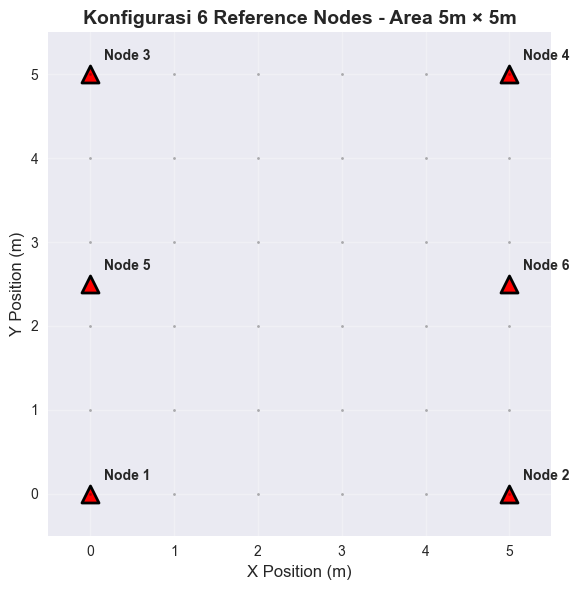

In [4]:
# ============================================================================
# CELL 2: Definisi Class Utama - StationaryIndoorLocalization
# ============================================================================

class StationaryIndoorLocalization:
    """
    Sistem Indoor Localization lengkap untuk target stasioner
    Berdasarkan paper: Indoor Localization System using WSN for Stationary and Moving Target
    """
    
    def __init__(self, reference_nodes=None):
        """
        Inisialisasi sistem lokalisasi
        """
        # Konfigurasi reference nodes (6 nodes untuk akurasi optimal)
        if reference_nodes is None:
            self.reference_nodes = np.array([
                (0, 0), (5, 0), (0, 5), (5, 5), (0, 2.5), (5, 2.5)
            ])
        else:
            self.reference_nodes = np.array(reference_nodes)
        
        # Parameter path loss model
        self.signal_strength_1m = -32.855625  # A dalam paper (dBm)
        self.path_loss_exponent = 2.65  # n dalam paper

        # Database fingerprint
        self.fingerprint_database = {}
        self.database_locations = []
        self.database_fingerprints = []
        
        # Data hasil evaluasi
        self.evaluation_results = {}
        
        print("=== Sistem Indoor Localization untuk Target Stasioner ===")
        print(f"📍 Reference Nodes: {len(self.reference_nodes)} nodes")
        print(f"📊 Koordinat Reference Nodes:")
        for i, (x, y) in enumerate(self.reference_nodes):
            print(f"   Node {i+1}: ({x}, {y})")
        print("✅ Status: Siap untuk training dan testing")
    
    def display_system_info(self):
        """
        Tampilkan informasi sistem
        """
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        
        # Plot reference nodes (tanpa label sehingga legend tidak muncul)
        ref_x = [node[0] for node in self.reference_nodes]
        ref_y = [node[1] for node in self.reference_nodes]
        ax.scatter(ref_x, ref_y, c='red', s=150, marker='^', 
                   edgecolors='black', linewidth=2)
        
        # Label reference nodes
        for i, (x, y) in enumerate(self.reference_nodes):
            ax.annotate(f'Node {i+1}', (x, y), xytext=(10, 10), 
                        textcoords='offset points', fontsize=10, fontweight='bold')
        
        # Grid area
        for x in range(6):
            for y in range(6):
                ax.plot(x, y, 'k.', alpha=0.3, markersize=4)
        
        ax.set_xlim(-0.5, 5.5)
        ax.set_ylim(-0.5, 5.5)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X Position (m)', fontsize=12)
        ax.set_ylabel('Y Position (m)', fontsize=12)
        ax.set_title('Konfigurasi 6 Reference Nodes - Area 5m × 5m', fontsize=14, fontweight='bold')
        # Legend call removed to hide the legend for reference nodes
        # ax.legend(fontsize=12)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()

# Inisialisasi sistem
localization_system = StationaryIndoorLocalization()
localization_system.display_system_info()

In [5]:
# ============================================================================
# CELL 3: Algoritma Range-based (Maximum Likelihood)
# ============================================================================

def add_range_based_methods():
    """
    Menambahkan method untuk Range-based localization
    """
    
    def rssi_to_distance(self, rssi):
        """
        Konversi RSSI ke jarak menggunakan path loss model
        Formula: RSSI(d) = A - 10*n*log10(d/d0)
        """
        if rssi >= self.signal_strength_1m:
            return 0.1  # Minimum distance
        
        power_ratio = (self.signal_strength_1m - rssi) / (10 * self.path_loss_exponent)
        distance = 10 ** power_ratio
        return max(distance, 0.1)
    
    def maximum_likelihood_estimation(self, rssi_measurements):
        """
        Maximum Likelihood Estimation sesuai dengan paper
        Menyelesaikan sistem persamaan non-linear
        """
        # Konversi RSSI ke jarak
        distances = [self.rssi_to_distance(rssi) for rssi in rssi_measurements]
        
        def objective_function(position):
            """
            Fungsi objektif untuk minimasi error
            """
            x, y = position
            errors = []
            
            for i, (ref_x, ref_y) in enumerate(self.reference_nodes):
                predicted_distance = np.sqrt((x - ref_x)**2 + (y - ref_y)**2)
                error = predicted_distance - distances[i]
                errors.append(error)
            
            return errors
        
        # Initial guess: centroid dari reference nodes
        x_init = np.mean(self.reference_nodes[:, 0])
        y_init = np.mean(self.reference_nodes[:, 1])
        
        try:
            # Solve menggunakan least squares
            result = least_squares(objective_function, [x_init, y_init])
            
            if result.success:
                rmse = np.sqrt(np.mean(np.array(result.fun)**2))
                return result.x, rmse, distances
            else:
                return None, float('inf'), distances
                
        except Exception as e:
            print(f"❌ Error dalam Maximum Likelihood: {e}")
            return None, float('inf'), distances
    
    def estimate_position_range_based(self, rssi_measurements):
        """
        Estimasi posisi menggunakan range-based technique
        """
        # Proses multiple measurements jika ada
        if isinstance(rssi_measurements, list) and len(rssi_measurements) > 0 and isinstance(rssi_measurements[0], list):
            # Rata-rata dari multiple measurements
            avg_rssi = [np.mean([measurement[i] for measurement in rssi_measurements]) 
                       for i in range(len(rssi_measurements[0]))]
        else:
            avg_rssi = rssi_measurements
        
        position, error, distances = self.maximum_likelihood_estimation(avg_rssi)
        
        return {
            'method': 'Maximum Likelihood (Range-based)',
            'position': position,
            'error': error,
            'distances': distances,
            'rssi_used': avg_rssi
        }
    
    # Tambahkan method ke class
    StationaryIndoorLocalization.rssi_to_distance = rssi_to_distance
    StationaryIndoorLocalization.maximum_likelihood_estimation = maximum_likelihood_estimation
    StationaryIndoorLocalization.estimate_position_range_based = estimate_position_range_based

# Tambahkan method ke class
add_range_based_methods()

print("✅ Range-based (Maximum Likelihood) algorithm berhasil ditambahkan!")

# Test konversi RSSI ke jarak
test_rssi = [-40, -50, -60, -70]
test_distances = [localization_system.rssi_to_distance(rssi) for rssi in test_rssi]

print(f"\n📊 Test konversi RSSI ke jarak:")
for rssi, dist in zip(test_rssi, test_distances):
    print(f"   RSSI: {rssi} dBm → Jarak: {dist:.2f} m")

✅ Range-based (Maximum Likelihood) algorithm berhasil ditambahkan!

📊 Test konversi RSSI ke jarak:
   RSSI: -40 dBm → Jarak: 1.86 m
   RSSI: -50 dBm → Jarak: 4.44 m
   RSSI: -60 dBm → Jarak: 10.58 m
   RSSI: -70 dBm → Jarak: 25.22 m


In [6]:
# ============================================================================
# CELL 4: Algoritma Location Fingerprint
# ============================================================================

def add_fingerprint_methods():
    """
    Menambahkan method untuk Location Fingerprint localization
    """
    
    def build_fingerprint_database(self, training_data):
        """
        Membangun fingerprint database dari data training
        """
        print("\n=== 🏗️ Membangun Fingerprint Database ===")
        
        self.fingerprint_database.clear()
        self.database_locations.clear()
        self.database_fingerprints.clear()
        
        for location, rssi_measurements in training_data.items():
            # Proses multiple measurements (5 kali pengukuran)
            if isinstance(rssi_measurements, list) and len(rssi_measurements) > 0 and isinstance(rssi_measurements[0], list):
                # Hitung rata-rata dari multiple measurements
                avg_fingerprint = []
                for node_idx in range(len(rssi_measurements[0])):
                    node_rssi_values = [measurement[node_idx] for measurement in rssi_measurements]
                    avg_rssi = np.mean(node_rssi_values)
                    avg_fingerprint.append(avg_rssi)
                
                # Simpan informasi statistik
                fingerprint_info = {
                    'avg_rssi': avg_fingerprint,
                    'std_rssi': [np.std([measurement[i] for measurement in rssi_measurements])
                               for i in range(len(rssi_measurements[0]))],
                    'raw_measurements': rssi_measurements,
                    'num_measurements': len(rssi_measurements)
                }
            elif isinstance(rssi_measurements, list):
                # Jika sudah rata-rata
                avg_fingerprint = rssi_measurements
                fingerprint_info = {
                    'avg_rssi': avg_fingerprint,
                    'std_rssi': [np.std([measurement[i] for measurement in rssi_measurements])
                               for i in range(len(rssi_measurements[0]))],
                    'raw_measurements': rssi_measurements,
                    'num_measurements': len(rssi_measurements)
                }
            else:
                # Jika sudah rata-rata
                avg_fingerprint = rssi_measurements
                fingerprint_info = {
                    'avg_rssi': avg_fingerprint,
                    'std_rssi': [0.0] * len(avg_fingerprint),
                    'raw_measurements': [rssi_measurements],
                    'num_measurements': 1
                }
            
            # Simpan ke database
            self.fingerprint_database[location] = fingerprint_info
            self.database_locations.append(location)
            self.database_fingerprints.append(avg_fingerprint)
        
        print(f"✅ Database berisi {len(self.database_locations)} lokasi fingerprint")
        print("🎯 Database fingerprint berhasil dibuat!")
    
    def euclidean_distance(self, fingerprint1, fingerprint2):
        """
        Hitung Euclidean distance antara dua fingerprint
        Sesuai dengan persamaan (5) dalam paper
        """
        return np.sqrt(sum((a - b)**2 for a, b in zip(fingerprint1, fingerprint2)))
    
    def k_nearest_neighbors(self, target_fingerprint, k=3):
        """
        Implementasi K-Nearest Neighbors untuk location fingerprint
        """
        if not self.database_fingerprints:
            raise ValueError("❌ Database fingerprint kosong! Jalankan build_fingerprint_database() terlebih dahulu")
        
        # Hitung jarak Euclidean ke semua fingerprint dalam database
        distances = []
        for i, db_fingerprint in enumerate(self.database_fingerprints):
            distance = self.euclidean_distance(target_fingerprint, db_fingerprint)
            distances.append((i, distance))
        
        # Urutkan berdasarkan jarak dan ambil k nearest
        distances.sort(key=lambda x: x[1])
        nearest_indices = [idx for idx, _ in distances[:k]]
        nearest_distances = [dist for _, dist in distances[:k]]
        
        return nearest_indices, nearest_distances
    
    def weighted_average_estimation(self, target_fingerprint, k=3):
        """
        Estimasi posisi menggunakan weighted average dari k-nearest neighbors
        """
        nearest_indices, nearest_distances = self.k_nearest_neighbors(target_fingerprint, k)
        
        # Jika ada exact match
        if nearest_distances[0] < 0.001:
            return self.database_locations[nearest_indices[0]], nearest_distances[0]
        
        # Weighted average berdasarkan inverse distance
        weights = []
        positions = []
        
        for idx, distance in zip(nearest_indices, nearest_distances):
            weight = 1.0 / (distance + 0.001)  # Hindari pembagian dengan nol
            weights.append(weight)
            positions.append(self.database_locations[idx])
        
        # Hitung weighted average
        total_weight = sum(weights)
        estimated_x = sum(w * pos[0] for w, pos in zip(weights, positions)) / total_weight
        estimated_y = sum(w * pos[1] for w, pos in zip(weights, positions)) / total_weight
        
        # Confidence score berdasarkan rata-rata jarak
        confidence = 1.0 / (np.mean(nearest_distances) + 0.001)
        
        return (estimated_x, estimated_y), confidence
    
    def estimate_position_fingerprint(self, target_rssi, k=3):
        """
        Estimasi posisi menggunakan fingerprint matching
        """
        # Proses multiple measurements jika ada
        if isinstance(target_rssi, list):
            # Rata-rata dari multiple measurements
            avg_rssi = [np.mean([measurement[i] for measurement in target_rssi])
                       for i in range(len(target_rssi[0]))]
        else:
            avg_rssi = target_rssi
        
        # Estimasi posisi
        position, confidence = self.weighted_average_estimation(avg_rssi, k)
        
        # Informasi nearest neighbors untuk debugging
        nearest_indices, nearest_distances = self.k_nearest_neighbors(avg_rssi, k)
        nearest_locations = [self.database_locations[idx] for idx in nearest_indices]
        
        return {
            'method': f'Location Fingerprint (k={k})',
            'position': position,
            'confidence': confidence,
            'nearest_distances': nearest_distances,
            'nearest_locations': nearest_locations,
            'rssi_used': avg_rssi,
            'k_value': k
        }
    
    # Tambahkan method ke class
    StationaryIndoorLocalization.build_fingerprint_database = build_fingerprint_database
    StationaryIndoorLocalization.euclidean_distance = euclidean_distance
    StationaryIndoorLocalization.k_nearest_neighbors = k_nearest_neighbors
    StationaryIndoorLocalization.weighted_average_estimation = weighted_average_estimation
    StationaryIndoorLocalization.estimate_position_fingerprint = estimate_position_fingerprint

# Tambahkan method ke class
add_fingerprint_methods()

print("✅ Location Fingerprint algorithm berhasil ditambahkan!")
print("🎯 Sistem siap untuk training fingerprint database!")

✅ Location Fingerprint algorithm berhasil ditambahkan!
🎯 Sistem siap untuk training fingerprint database!


📂 Loading sample dataset...
✅ Training data: 12 lokasi
✅ Testing data: 16 lokasi
📊 Setiap lokasi memiliki 5 measurements dari 6 reference nodes


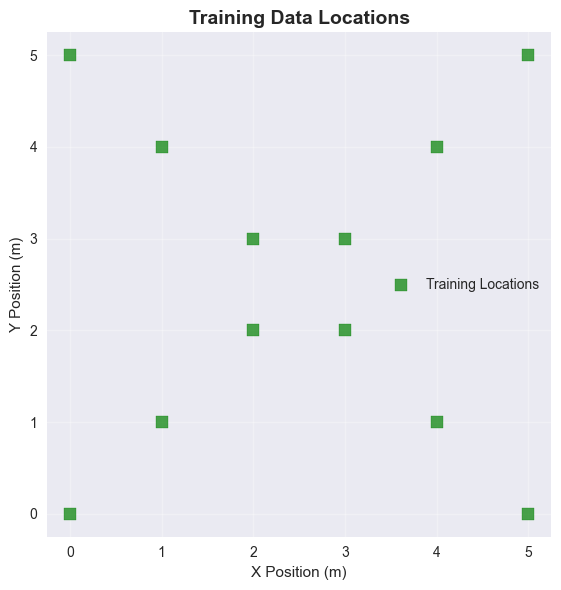

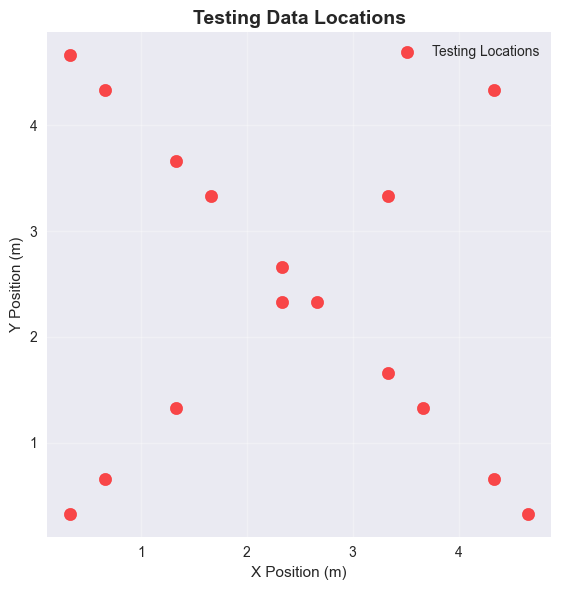

In [7]:
# ============================================================================
# CELL 5: Load Dataset dan Persiapan Data
# ============================================================================

def load_sample_dataset():
    """
    Load sample dataset sesuai dengan format Excel Anda
    Sesuaikan dengan data RSSI yang sebenarnya
    """
    
    print("📂 Loading sample dataset...")
    
    # Data training (koordinat hijau dari Excel Anda)
    # Format: {(x,y): [[rssi1_measurement1, rssi2_measurement1, ..., rssi6_measurement1],
    #                  [rssi1_measurement2, rssi2_measurement2, ..., rssi6_measurement2], ...]}
    
    training_data = {
        # Baris bawah (y=0)
        (0, 0): [
            [-26, -43, -47, -51, -36, -50],
            [-26, -46, -50, -61, -37, -50],
            [-26, -45, -48, -65, -40, -50],
            [-26, -49, -48, -50, -36, -51],
            [-26, -46, -46, -57, -40, -52]
        ],
        (1, 1): [
            [-32, -46, -47, -48, -38, -45],
            [-32, -42, -47, -49, -38, -46],
            [-36, -44, -51, -56, -38, -46],
            [-33, -42, -46, -51, -38, -45],
            [-33, -44, -44, -47, -38, -47]
        ],
        (2, 2): [
            [-37, -40, -45, -50, -38, -42],
            [-40, -44, -44, -46, -36, -40],
            [-39, -40, -47, -46, -38, -40],
            [-42, -43, -44, -48, -38, -38],
            [-41, -42, -43, -46, -37, -42]
        ],
        (3, 3): [
            [-42, -41, -45, -42, -42, -40],
            [-41, -40, -47, -40, -42, -40],
            [-43, -40, -44, -40, -41, -37],
            [-46, -42, -42, -42, -44, -38],
            [-42, -42, -42, -42, -40, -38]
        ],
        (4, 4): [
            [-47, -45, -45, -37, -44, -33],
            [-48, -43, -44, -35, -44, -34],
            [-48, -43, -43, -35, -42, -34],
            [-46, -42, -47, -34, -46, -35],
            [-48, -43, -45, -36, -43, -34]
        ],
        (5, 5): [
            [-52, -48, -43, -27, -45, -40],
            [-50, -52, -46, -27, -45, -39],
            [-54, -51, -47, -27, -48, -40],
            [-50, -48, -43, -27, -47, -40],
            [-53, -48, -47, -27, -46, -40]
        ],
        
        # Baris tengah (y=2.5)
        (5, 0): [
            [-44, -26, -53, -51, -50, -35],  # Tabel 1
            [-46, -27, -51, -53, -51, -34],  # Tabel 2
            [-45, -26, -49, -51, -48, -36],  # Tabel 3
            [-42, -26, -59, -47, -53, -35],  # Tabel 4
            [-44, -26, -55, -49, -55, -38],  # Tabel 5
        ],
        (4, 1): [
            [-44, -33, -58, -43, -41, -35],
            [-48, -32, -57, -44, -41, -36],
            [-46, -34, -61, -48, -44, -36],
            [-46, -34, -49, -42, -46, -36],
            [-49, -37, -49, -44, -52, -34],
        ],
        (3, 2): [
            [-40, -40, -44, -42, -40, -38],
            [-40, -37, -51, -44, -42, -38],
            [-40, -40, -45, -44, -42, -39],
            [-43, -39, -44, -40, -42, -37],
            [-42, -42, -44, -43, -42, -38],
        ],
        (2, 3): [
            [-40, -43, -42, -49, -37, -43],
            [-39, -43, -42, -46, -38, -40],
            [-40, -44, -42, -46, -36, -40],
            [-41, -45, -43, -48, -37, -41],
            [-42, -44, -39, -43, -37, -40],
        ],
        (1, 4): [
            [-42, -51, -35, -44, -34, -38],
            [-42, -49, -36, -47, -34, -45],
            [-43, -49, -35, -47, -34, -47],
            [-42, -49, -36, -44, -35, -43],
            [-43, -54, -35, -51, -35, -44],
        ],
        (0, 5): [
            [-46, -55, -26, -48, -38, -51],
            [-46, -51, -26, -53, -40, -48],
            [-49, -48, -26, -53, -40, -48],
            [-49, -60, -26, -47, -43, -47],
            [-47, -52, -27, -49, -40, -46],
        ],
    }
    
    # Data testing (koordinat merah dari Excel Anda)
    testing_data = {
    (0.33, 0.33): [
        [-28, -48, -48, -48, -38, -48],  # Tabel 1
        [-28, -44, -52, -51, -37, -51],  # Tabel 2
        [-28, -44, -49, -49, -37, -48],  # Tabel 3
        [-28, -44, -50, -49, -39, -48],  # Tabel 4
        [-29, -50, -46, -59, -37, -47],  # Tabel 5
    ],
    (0.66, 0.66): [
        [-30, -42, -47, -52, -38, -46],  # Tabel 1
        [-30, -46, -46, -50, -38, -47],  # Tabel 2
        [-31, -47, -44, -50, -36, -47],  # Tabel 3
        [-31, -47, -47, -53, -40, -47],  # Tabel 4
        [-31, -43, -44, -50, -37, -52],  # Tabel 5
    ],
    (1.33, 1.33): [
        [-32, -45, -47, -47, -38, -44],  # Tabel 1
        [-34, -45, -47, -50, -38, -46],  # Tabel 2
        [-37, -41, -48, -50, -38, -42],  # Tabel 3
        [-36, -44, -44, -52, -38, -42],  # Tabel 4
        [-36, -43, -44, -52, -37, -43],  # Tabel 5
    ],
    (2.33, 2.33): [
        [-41, -44, -43, -48, -38, -40],  # Tabel 1
        [-45, -40, -43, -45, -40, -40],  # Tabel 2
        [-41, -41, -43, -45, -38, -39],  # Tabel 3
        [-42, -46, -43, -44, -38, -40],  # Tabel 4
        [-44, -43, -43, -45, -38, -40],  # Tabel 5
    ],
    (3.33, 3.33): [
        [-44, -43, -43, -38, -42, -37],  # Tabel 1
        [-42, -39, -42, -40, -44, -37],  # Tabel 2
        [-45, -42, -42, -41, -44, -36],  # Tabel 3
        [-48, -41, -46, -39, -44, -37],  # Tabel 4
        [-52, -40, -43, -41, -40, -36],  # Tabel 5
    ],
    (4.33, 4.33): [
        [-48, -44, -44, -32, -47, -34],  # Tabel 1
        [-49, -44, -45, -33, -45, -33],  # Tabel 2
        [-50, -44, -44, -31, -41, -34],  # Tabel 3
        [-50, -42, -46, -32, -47, -34],  # Tabel 4
        [-52, -45, -45, -32, -47, -35],  # Tabel 5
    ],
    (4.66, 0.33): [
        [-44, -28, -60, -49, -48, -37],  # Tabel 1
        [-44, -28, -52, -49, -54, -35],  # Tabel 2
        [-47, -29, -60, -50, -47, -37],  # Tabel 3
        [-53, -30, -55, -56, -48, -36],  # Tabel 4
        [-49, -29, -55, -48, -50, -35],  # Tabel 5
    ],
    (4.33, 0.66): [
        [-45, -30, -46, -46, -48, -35],  # Tabel 1
        [-46, -31, -53, -45, -46, -36],  # Tabel 2
        [-46, -30, -50, -45, -47, -36],  # Tabel 3
        [-46, -31, -51, -44, -46, -34],  # Tabel 4
        [-52, -31, -52, -41, -47, -34],  # Tabel 5
    ],
    (3.66, 1.33): [
        [-42, -34, -52, -45, -44, -35],
        [-46, -33, -48, -42, -43, -37],
        [-46, -34, -51, -47, -46, -36],
        [-42, -35, -51, -48, -50, -36],
        [-42, -38, -48, -44, -47, -34],
    ],
    (3.33, 1.66): [
        [-42, -36, -49, -46, -43, -36],
        [-42, -36, -46, -45, -43, -36],
        [-43, -38, -47, -46, -40, -36],
        [-45, -36, -48, -43, -42, -35],
        [-44, -40, -48, -46, -43, -35],
    ],
    (2.66, 2.33): [
        [-41, -41, -48, -46, -40, -38],
        [-42, -37, -42, -44, -50, -39],
        [-42, -41, -43, -43, -41, -38],
        [-41, -42, -48, -42, -41, -37],
        [-42, -41, -46, -45, -41, -40],
    ],
    (2.33, 2.66): [
        [-42, -42, -41, -47, -40, -40],
        [-41, -42, -42, -45, -38, -39],
        [-41, -45, -46, -43, -41, -40],
        [-46, -43, -45, -43, -40, -40],
        [-42, -44, -42, -47, -38, -41],
    ],
    (1.66, 3.33): [
        [-39, -43, -39, -45, -35, -42],
        [-40, -45, -40, -46, -36, -42],
        [-41, -45, -43, -47, -37, -42],
        [-42, -48, -38, -42, -36, -43],
        [-44, -50, -39, -43, -35, -42],
    ],
    (1.33, 3.66): [
        [-42, -48, -38, -45, -35, -42],
        [-42, -46, -38, -46, -35, -43],
        [-42, -45, -37, -49, -35, -43],
        [-42, -49, -37, -48, -35, -43],
        [-43, -50, -38, -49, -37, -41],
    ],
    (0.66, 4.33): [
        [-46, -47, -33, -45, -35, -47],
        [-46, -50, -33, -48, -35, -47],
        [-44, -44, -31, -46, -35, -46],
        [-44, -48, -32, -47, -35, -46],
        [-43, -53, -32, -53, -34, -46],
    ],
    (0.33, 4.66): [
        [-47, -43, -30, -47, -36, -45],
        [-47, -50, -30, -47, -37, -45],
        [-44, -49, -30, -47, -35, -49],
        [-45, -51, -29, -49, -36, -49],
        [-44, -58, -30, -52, -34, -48],
    ]

    }
    
    print(f"✅ Training data: {len(training_data)} lokasi")
    print(f"✅ Testing data: {len(testing_data)} lokasi")
    print(f"📊 Setiap lokasi memiliki 5 measurements dari 6 reference nodes")
    
    return training_data, testing_data

# Load dataset
training_data, testing_data = load_sample_dataset()
# Plot Training Data
fig_train, ax_train = plt.subplots(figsize=(8, 6))
train_x = [loc[0] for loc in training_data.keys()]
train_y = [loc[1] for loc in training_data.keys()]
ax_train.scatter(train_x, train_y, c='green', s=80, marker='s', alpha=0.7, label='Training Locations')
ax_train.set_title('Training Data Locations', fontsize=14, fontweight='bold')
ax_train.grid(True, alpha=0.3)
ax_train.set_xlabel('X Position (m)')
ax_train.set_ylabel('Y Position (m)')
ax_train.legend()
ax_train.set_aspect('equal')
plt.tight_layout()
plt.show()

# Plot Testing Data
fig_test, ax_test = plt.subplots(figsize=(8, 6))
test_x = [loc[0] for loc in testing_data.keys()]
test_y = [loc[1] for loc in testing_data.keys()]
ax_test.scatter(test_x, test_y, c='red', s=80, marker='o', alpha=0.7, label='Testing Locations')
ax_test.set_title('Testing Data Locations', fontsize=14, fontweight='bold')
ax_test.grid(True, alpha=0.3)
ax_test.set_xlabel('X Position (m)')
ax_test.set_ylabel('Y Position (m)')
ax_test.legend()
ax_test.set_aspect('equal')
plt.tight_layout()
plt.show()

🏗️ Membangun Fingerprint Database...

=== 🏗️ Membangun Fingerprint Database ===
✅ Database berisi 12 lokasi fingerprint
🎯 Database fingerprint berhasil dibuat!


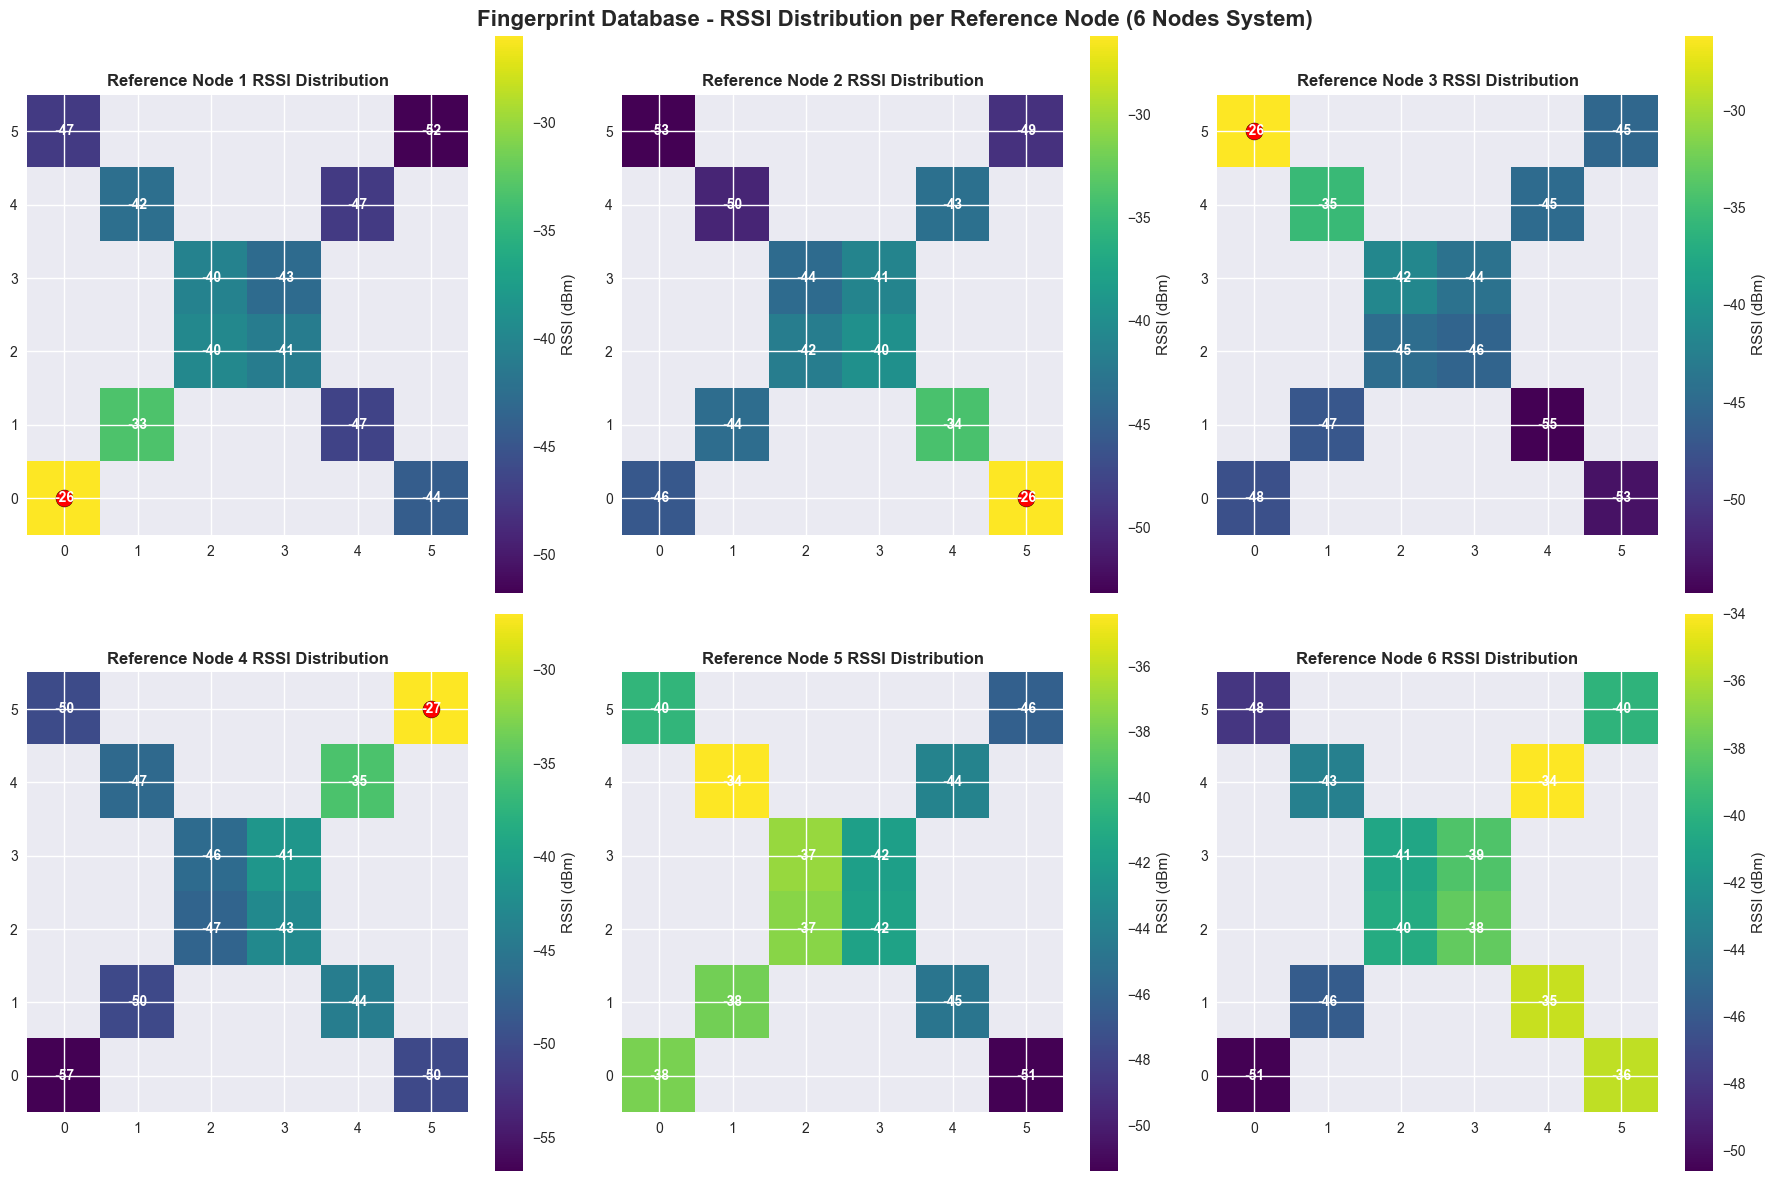

In [8]:
# ============================================================================
# CELL 6: Training Fingerprint Database
# ============================================================================

# Build fingerprint database
print("🏗️ Membangun Fingerprint Database...")
localization_system.build_fingerprint_database(training_data)

# Visualisasi fingerprint database
def visualize_fingerprint_database():
    """
    Visualisasi fingerprint database dengan heatmap
    """
    if not localization_system.database_locations:
        print("❌ Database fingerprint kosong!")
        return
    
    # Buat heatmap untuk setiap reference node
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for node_idx in range(6):
        # Ekstrak RSSI untuk node ini dari semua lokasi
        rssi_values = []
        locations = []
        
        for loc, fingerprint in zip(localization_system.database_locations, 
                                      localization_system.database_fingerprints):
            rssi_values.append(fingerprint[node_idx])
            locations.append(loc)
        
        # Buat grid untuk heatmap
        x_coords = sorted(list(set([loc[0] for loc in locations])))
        y_coords = sorted(list(set([loc[1] for loc in locations])))

        # Buat matrix RSSI
        rssi_matrix = np.full((len(y_coords), len(x_coords)), np.nan)
        
        for (x, y), rssi in zip(locations, rssi_values):
            x_idx = x_coords.index(x)
            y_idx = y_coords.index(y)
            rssi_matrix[len(y_coords)-1-y_idx, x_idx] = rssi
        
        # Plot heatmap
        im = axes[node_idx].imshow(rssi_matrix, cmap='viridis', aspect='equal')
        axes[node_idx].set_title(f'Reference Node {node_idx+1} RSSI Distribution', 
                                 fontweight='bold')
        
        # Set ticks
        axes[node_idx].set_xticks(range(len(x_coords)))
        axes[node_idx].set_xticklabels(x_coords)
        axes[node_idx].set_yticks(range(len(y_coords)))
        axes[node_idx].set_yticklabels(y_coords[::-1])
        
        # Colorbar
        plt.colorbar(im, ax=axes[node_idx], label='RSSI (dBm)')
        
        # Tambahkan nilai RSSI pada setiap cell
        for i in range(len(y_coords)):
            for j in range(len(x_coords)):
                if not np.isnan(rssi_matrix[i, j]):
                    axes[node_idx].text(j, i, f'{rssi_matrix[i, j]:.0f}', 
                                        ha='center', va='center', color='white', fontweight='bold')
        
        # Tambahkan tampilan node (reference node) ke dalam heatmap tanpa legenda
        ref_coord = tuple(localization_system.reference_nodes[node_idx])
        if ref_coord[0] in x_coords and ref_coord[1] in y_coords:
            x_idx = x_coords.index(ref_coord[0])
            y_idx = y_coords.index(ref_coord[1])
            # Karena imshow membalik urutan y, maka sesuaikan index y
            axes[node_idx].scatter(x_idx, len(y_coords)-1-y_idx, 
                                   c='red', marker='o', s=150, edgecolors='black')
    
    plt.suptitle('Fingerprint Database - RSSI Distribution per Reference Node (6 Nodes System)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualisasi database
visualize_fingerprint_database()


In [9]:
# ============================================================================
# CELL 6: Training Fingerprint Database (lanjutan)
# ============================================================================

# Statistik database
def analyze_database_statistics():
    """
    Analisis statistik database fingerprint
    """
    print("📊 ANALISIS STATISTIK FINGERPRINT DATABASE")
    print("="*50)
    
    # Ekstrak semua RSSI values
    all_rssi = []
    for fingerprint in localization_system.database_fingerprints:
        all_rssi.extend(fingerprint)
    
    print(f"Total fingerprint locations: {len(localization_system.database_locations)}")
    print(f"Reference nodes per location: {len(localization_system.database_fingerprints[0])}")
    print(f"Total RSSI measurements: {len(all_rssi)}")
    print(f"RSSI range: {min(all_rssi):.1f} to {max(all_rssi):.1f} dBm")
    print(f"RSSI mean: {np.mean(all_rssi):.1f} dBm")
    print(f"RSSI std: {np.std(all_rssi):.1f} dBm")
    
    # Analisis per reference node
    print(f"\n📡 STATISTIK PER REFERENCE NODE:")
    for node_idx in range(6):
        node_rssi = [fp[node_idx] for fp in localization_system.database_fingerprints]
        print(f"Node {node_idx+1}: Mean={np.mean(node_rssi):.1f}dBm, Std={np.std(node_rssi):.1f}dBm")

analyze_database_statistics()

📊 ANALISIS STATISTIK FINGERPRINT DATABASE
Total fingerprint locations: 12
Reference nodes per location: 6
Total RSSI measurements: 72
RSSI range: -56.8 to -26.0 dBm
RSSI mean: -42.6 dBm
RSSI std: 6.6 dBm

📡 STATISTIK PER REFERENCE NODE:
Node 1: Mean=-41.9dBm, Std=6.6dBm
Node 2: Mean=-42.7dBm, Std=7.0dBm
Node 3: Mean=-44.2dBm, Std=7.2dBm
Node 4: Mean=-44.8dBm, Std=7.4dBm
Node 5: Mean=-41.2dBm, Std=4.6dBm
Node 6: Mean=-40.9dBm, Std=5.0dBm


In [10]:
def add_evaluation_methods():
    """
    Menambahkan method untuk evaluasi sistem
    """
    
    def calculate_accuracy(self, estimated_pos, actual_pos):
        """
        Hitung akurasi estimasi dalam meter
        """
        if estimated_pos is None:
            return float('inf')
        return np.sqrt((estimated_pos[0] - actual_pos[0])**2 + 
                       (estimated_pos[1] - actual_pos[1])**2)

    def evaluate_system_comprehensive(self, testing_data, k_values=list(range(1, 11))):
        """
        Evaluasi sistem dengan mencari k terbaik untuk fingerprint KNN, 
        lalu menampilkan fingerprint estimation dengan k terbaik tersebut.
        """
        print("\n=== 🔍 EVALUASI SISTEM INDOOR LOCALIZATION ===")
        # Pada tabel nanti fingerprint akan ditampilkan dengan k terbaik.
        print("Posisi Aktual\t\tRange-based\t\tFingerprint (k=?)\tError Range\tError Fingerprint")
        print("-" * 110)
        
        results = {
            'range_based': {'errors': [], 'positions': []},
            'fingerprint': {k: {'errors': [], 'positions': []} for k in k_values}
        }
        
        detailed_results = []  # Buat list untuk menampung hasil per sampel
        
        # Pertama: evaluasi untuk tiap sampel dengan semua k
        for actual_pos, rssi_measurements in testing_data.items():
            result_entry = {'actual_position': actual_pos}
            
            # Estimasi range-based
            try:
                range_result = self.estimate_position_range_based(rssi_measurements)
                range_error = self.calculate_accuracy(range_result['position'], actual_pos)
                results['range_based']['errors'].append(range_error)
                results['range_based']['positions'].append(range_result['position'])
                result_entry['range_based'] = {
                    'position': range_result['position'],
                    'error': range_error,
                    'distances': range_result.get('distances', None)
                }
            except Exception as e:
                print(f"❌ Error range-based untuk {actual_pos}: {e}")
                results['range_based']['errors'].append(float('inf'))
                results['range_based']['positions'].append(None)
                result_entry['range_based'] = {'position': None, 'error': float('inf')}
            
            # Evaluasi fingerprint untuk semua nilai k
            result_entry['fingerprint'] = {}
            for k in k_values:
                try:
                    fp_result = self.estimate_position_fingerprint(rssi_measurements, k)
                    fp_error = self.calculate_accuracy(fp_result['position'], actual_pos)
                    results['fingerprint'][k]['errors'].append(fp_error)
                    results['fingerprint'][k]['positions'].append(fp_result['position'])
                    result_entry['fingerprint'][k] = {
                        'position': fp_result['position'],
                        'error': fp_error,
                        'confidence': fp_result.get('confidence', None),
                        'nearest_locations': fp_result.get('nearest_locations', None)
                    }
                except Exception as e:
                    print(f"❌ Error fingerprint k={k} untuk {actual_pos}: {e}")
                    results['fingerprint'][k]['errors'].append(float('inf'))
                    results['fingerprint'][k]['positions'].append(None)
                    result_entry['fingerprint'][k] = {'position': None, 'error': float('inf')}
            
            detailed_results.append(result_entry)
        
        # Hitung rata-rata error untuk tiap k dan cari k terbaik (min error)
        avg_fp_errors = {}
        for k in k_values:
            valid_errors = [e for e in results['fingerprint'][k]['errors'] if e != float('inf')]
            avg_fp_errors[k] = np.mean(valid_errors) if valid_errors else float('inf')
        
        best_k = min(avg_fp_errors, key=avg_fp_errors.get)
        
        # Hitung rata-rata error untuk range-based
        valid_range_errors = [e for e in results['range_based']['errors'] if e != float('inf')]
        avg_range_error = np.mean(valid_range_errors) if valid_range_errors else float('inf')
        
        print(f"\n=> K terbaik untuk Fingerprint adalah k = {best_k} dengan error rata-rata {avg_fp_errors[best_k]:.2f} m\n")
        
        # Tampilkan hasil per sampel dengan fingerprint menggunakan k terbaik
        for entry in detailed_results:
            actual_pos = entry['actual_position']
            range_data = entry['range_based']
            fp_data = entry['fingerprint'][best_k]
            
            # Format tampilan, cek apakah terdapat nilai atau tidak
            if range_data['position'] is not None:
                range_str = f"({range_data['position'][0]:.2f}, {range_data['position'][1]:.2f})"
            else:
                range_str = "None"
            if fp_data['position'] is not None:
                fp_str = f"({fp_data['position'][0]:.2f}, {fp_data['position'][1]:.2f})"
            else:
                fp_str = "None"
            
            print(f"({actual_pos[0]:.2f}, {actual_pos[1]:.2f})\t\t{range_str}\t\t{fp_str}\t\t{range_data['error']:.2f}m\t\t{fp_data['error']:.2f}m")
        
        print(f"\n=== 📊 HASIL EVALUASI (Menggunakan Fingerprint dengan k = {best_k}) ===")
        print(f"Maximum Likelihood (Range-based): {avg_range_error:.2f} m")
        print(f"Location Fingerprint (k={best_k}): {avg_fp_errors[best_k]:.2f} m")
        
        # Simpan hasil analisis lebih lanjut
        self.evaluation_results = {
            'summary': {
                'range_based_avg_error': avg_range_error,
                'fingerprint_avg_errors': avg_fp_errors,
                'best_k': best_k
            },
            'detailed': detailed_results,
            'raw_results': results
        }
        return self.evaluation_results

    # Tambahkan method ke class
    StationaryIndoorLocalization.calculate_accuracy = calculate_accuracy
    StationaryIndoorLocalization.evaluate_system_comprehensive = evaluate_system_comprehensive

# Tambahkan method ke class
add_evaluation_methods()

# Jalankan evaluasi sistem
print("🚀 Menjalankan evaluasi sistem...")
results = localization_system.evaluate_system_comprehensive(testing_data)

🚀 Menjalankan evaluasi sistem...

=== 🔍 EVALUASI SISTEM INDOOR LOCALIZATION ===
Posisi Aktual		Range-based		Fingerprint (k=?)	Error Range	Error Fingerprint
--------------------------------------------------------------------------------------------------------------

=> K terbaik untuk Fingerprint adalah k = 2 dengan error rata-rata 0.18 m

(0.33, 0.33)		(1.19, 0.94)		(0.50, 0.50)		1.06m		0.24m
(0.66, 0.66)		(1.25, 1.23)		(0.68, 0.68)		0.82m		0.03m
(1.33, 1.33)		(1.84, 1.57)		(1.32, 1.32)		0.56m		0.02m
(2.33, 2.33)		(2.36, 2.35)		(2.00, 2.54)		0.04m		0.39m
(3.33, 3.33)		(2.98, 2.70)		(3.42, 3.42)		0.72m		0.13m
(4.33, 4.33)		(3.61, 3.42)		(4.32, 4.32)		1.16m		0.02m
(4.66, 0.33)		(4.45, 0.34)		(4.63, 0.37)		0.21m		0.05m
(4.33, 0.66)		(3.83, 1.52)		(4.38, 0.62)		0.99m		0.06m
(3.66, 1.33)		(3.37, 1.64)		(3.60, 1.40)		0.42m		0.09m
(3.33, 1.66)		(2.98, 1.92)		(3.00, 2.42)		0.43m		0.83m
(2.66, 2.33)		(2.74, 2.15)		(3.00, 2.37)		0.20m		0.34m
(2.33, 2.66)		(2.39, 2.37)		(2.00, 2.53)		0.30m		0.3

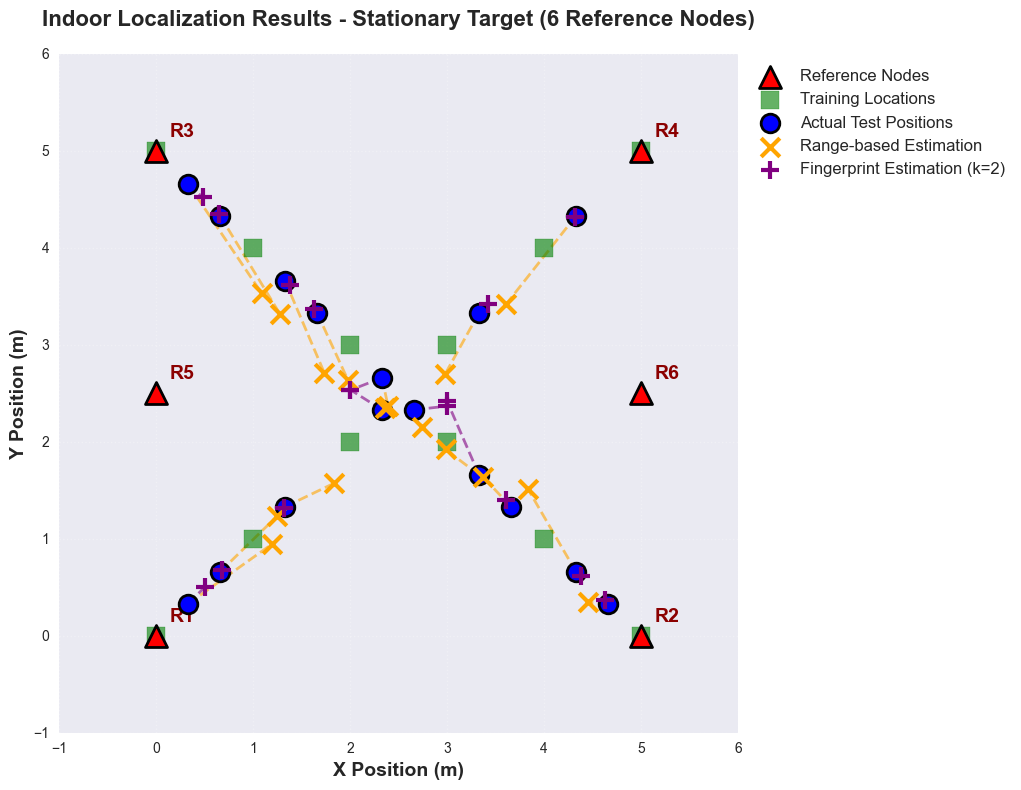

✅ Grafik utama hasil lokalisasi telah ditampilkan.

Ringkasan koordinat hasil pemosisian:
Test 1:
  Actual: (0.33, 0.33)
  Range-based: (1.19, 0.94) (Error: 1.06)
  Fingerprint (k=2): (0.50, 0.50) (Error: 0.24)
Test 2:
  Actual: (0.66, 0.66)
  Range-based: (1.25, 1.23) (Error: 0.82)
  Fingerprint (k=2): (0.68, 0.68) (Error: 0.03)
Test 3:
  Actual: (1.33, 1.33)
  Range-based: (1.84, 1.57) (Error: 0.56)
  Fingerprint (k=2): (1.32, 1.32) (Error: 0.02)
Test 4:
  Actual: (2.33, 2.33)
  Range-based: (2.36, 2.35) (Error: 0.04)
  Fingerprint (k=2): (2.00, 2.54) (Error: 0.39)
Test 5:
  Actual: (3.33, 3.33)
  Range-based: (2.98, 2.70) (Error: 0.72)
  Fingerprint (k=2): (3.42, 3.42) (Error: 0.13)
Test 6:
  Actual: (4.33, 4.33)
  Range-based: (3.61, 3.42) (Error: 1.16)
  Fingerprint (k=2): (4.32, 4.32) (Error: 0.02)
Test 7:
  Actual: (4.66, 0.33)
  Range-based: (4.45, 0.34) (Error: 0.21)
  Fingerprint (k=2): (4.63, 0.37) (Error: 0.05)
Test 8:
  Actual: (4.33, 0.66)
  Range-based: (3.83, 1.52) (Err

In [11]:
import matplotlib.pyplot as plt

def plot_main_localization_result():
    """
    Plot hanya grafik utama hasil lokalisasi indoor
    Menampilkan:
    - Reference Nodes (segitiga merah)
    - Training Locations (kotak hijau)
    - Actual Test Positions (lingkaran biru)
    - Range-based Estimations (silang oranye)
    - Fingerprint Estimations (tanda plus ungu, k=2)
    - Garis penghubung antara actual dan estimasi
    - Ringkasan lokasi terprediksi (summary)
    """
    if not localization_system.evaluation_results:
        print("❌ Belum ada hasil evaluasi untuk divisualisasi.")
        return

    # Buat figure besar khusus untuk grafik utama
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # Plot Reference Nodes (segitiga merah besar)
    ref_x = [node[0] for node in localization_system.reference_nodes]
    ref_y = [node[1] for node in localization_system.reference_nodes]
    ax.scatter(ref_x, ref_y, c='red', s=250, marker='^',
               label='Reference Nodes', edgecolors='black', linewidth=2, zorder=5)

    # Anotasi R1, R2, ... di samping reference nodes
    for i, (x, y) in enumerate(localization_system.reference_nodes):
        ax.annotate(f'R{i+1}', (x, y), xytext=(10, 10),
                    textcoords='offset points', fontsize=14, fontweight='bold', color='darkred')

    # Plot Training Locations (kotak hijau)
    if localization_system.database_locations:
        train_x = [loc[0] for loc in localization_system.database_locations]
        train_y = [loc[1] for loc in localization_system.database_locations]
        ax.scatter(train_x, train_y, c='green', s=150, marker='s',
                   alpha=0.6, label='Training Locations', zorder=3)

    # Ambil hasil evaluasi detail
    detailed_results = localization_system.evaluation_results['detailed']

    # Plot Actual Test Positions (lingkaran biru)
    actual_x = [result['actual_position'][0] for result in detailed_results]
    actual_y = [result['actual_position'][1] for result in detailed_results]
    ax.scatter(actual_x, actual_y, c='blue', s=180, marker='o',
               label='Actual Test Positions', edgecolors='black', linewidth=2, zorder=4)

    # Plot Range-based Estimations (silang oranye)
    range_positions = [result['range_based']['position'] for result in detailed_results 
                       if result['range_based']['position'] is not None]
    if range_positions:
        range_x = [pos[0] for pos in range_positions]
        range_y = [pos[1] for pos in range_positions]
        ax.scatter(range_x, range_y, c='orange', s=180, marker='x',
                   label='Range-based Estimation', linewidth=3, zorder=4)

    # Plot Fingerprint Estimations (tanda plus ungu, k=2)
    fp_positions = [result['fingerprint'][2]['position'] for result in detailed_results 
                    if result['fingerprint'][2]['position'] is not None]
    if fp_positions:
        fp_x = [pos[0] for pos in fp_positions]
        fp_y = [pos[1] for pos in fp_positions]
        ax.scatter(fp_x, fp_y, c='purple', s=180, marker='+',
                   label='Fingerprint Estimation (k=2)', linewidth=3, zorder=4)

    # Gambar garis penghubung antara actual dan estimasi
    for result in detailed_results:
        actual_pos = result['actual_position']
        # Garis ke estimasi range-based
        if result['range_based']['position'] is not None:
            range_pos = result['range_based']['position']
            ax.plot([actual_pos[0], range_pos[0]], [actual_pos[1], range_pos[1]],
                    color='orange', alpha=0.6, linewidth=2, linestyle='--', zorder=2)
        # Garis ke estimasi fingerprint (k=2)
        if result['fingerprint'][2]['position'] is not None:
            fp_pos = result['fingerprint'][2]['position']
            ax.plot([actual_pos[0], fp_pos[0]], [actual_pos[1], fp_pos[1]],
                    color='purple', alpha=0.6, linewidth=2, linestyle='--', zorder=2)

    # Tambahkan ringkasan tentang lokasi terprediksi (summary)

    # Atur batas sumbu
    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 6)

    # Tambahkan grid, label, judul
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_xlabel('X Position (m)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=14, fontweight='bold')
    ax.set_title('Indoor Localization Results - Stationary Target (6 Reference Nodes)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12, framealpha=0.9)
    ax.set_aspect('equal')  # Jaga rasio sumbu X dan Y

    plt.tight_layout()
    plt.show()

    print("✅ Grafik utama hasil lokalisasi telah ditampilkan.")
    # Ringkasan koordinat hasil pemosisian dan perhitungan error (Euclidean distance)
    print("\nRingkasan koordinat hasil pemosisian:")
    for i, result in enumerate(detailed_results):
        actual = result['actual_position']
        rb = result['range_based']['position']
        fp = result['fingerprint'][2]['position']

        def format_coord(pos):
            return f"({pos[0]:.2f}, {pos[1]:.2f})" if pos is not None else "None"
        
        # Hitung error dengan Euclidean distance jika estimasi tersedia
        error_rb = ((actual[0] - rb[0])**2 + (actual[1] - rb[1])**2)**0.5 if rb is not None else None
        error_fp = ((actual[0] - fp[0])**2 + (actual[1] - fp[1])**2)**0.5 if fp is not None else None

        def format_error(err):
            return f"{err:.2f}" if err is not None else "None"

        print(f"Test {i+1}:")
        print(f"  Actual: {format_coord(actual)}")
        print(f"  Range-based: {format_coord(rb)} (Error: {format_error(error_rb)})")
        print(f"  Fingerprint (k=2): {format_coord(fp)} (Error: {format_error(error_fp)})")

plot_main_localization_result()



SISTEM PERFORMANCE SUMMARY:
• Range-based avg error: 0.70m
• Fingerprint avg error: 0.18m
• Improvement: 74.3%
• Paper target achieved: V



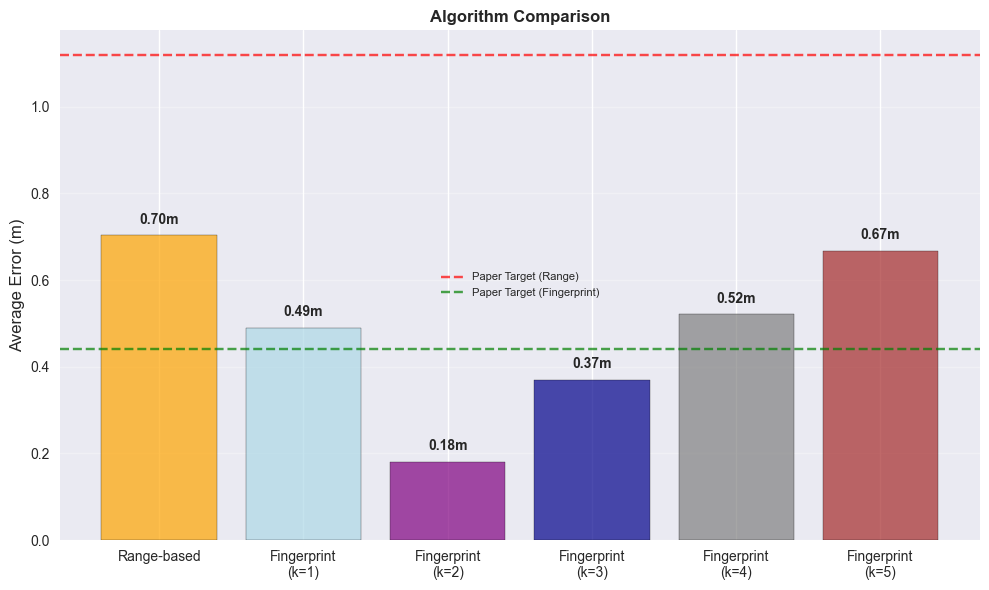

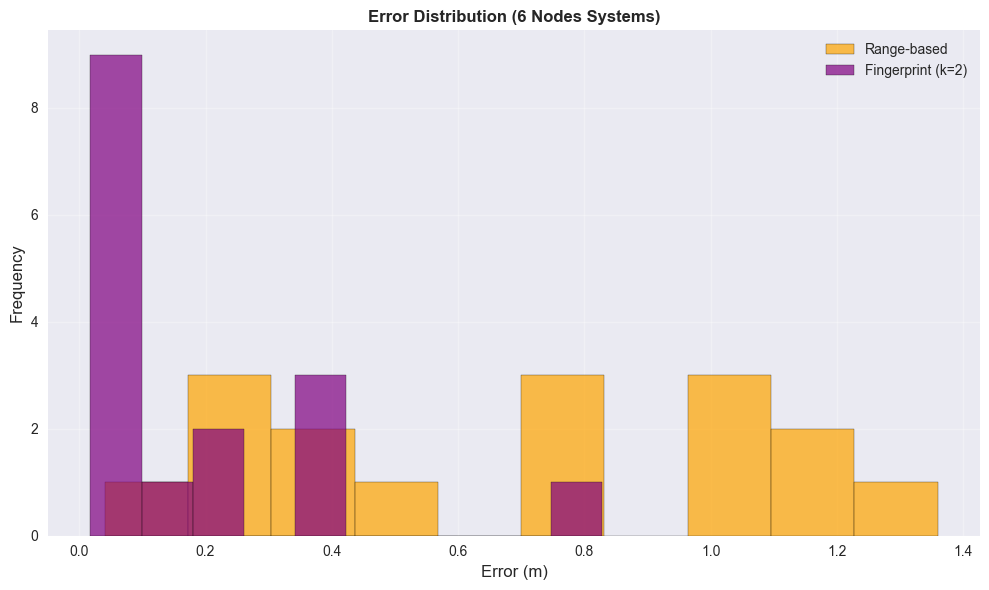

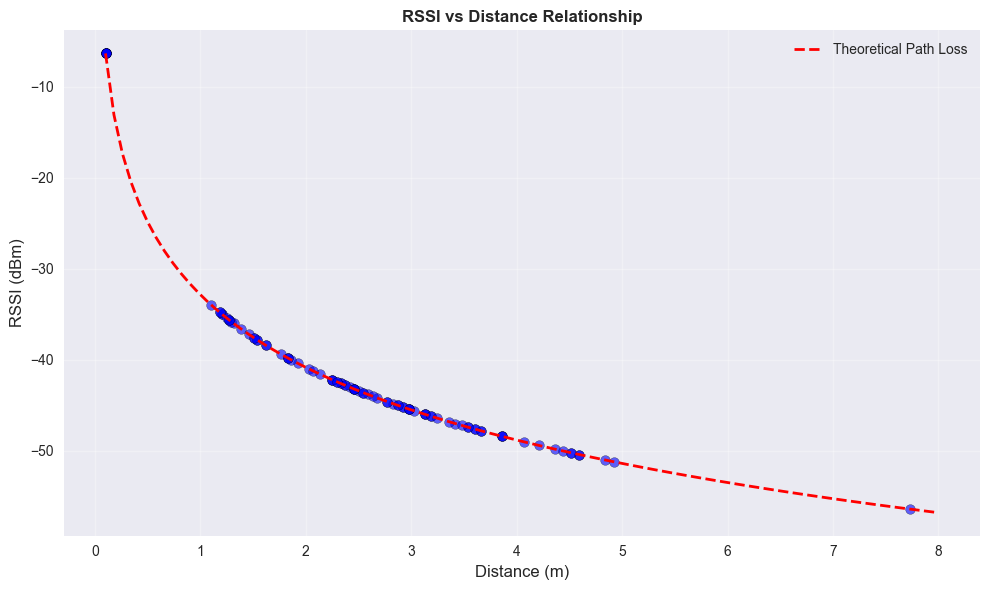

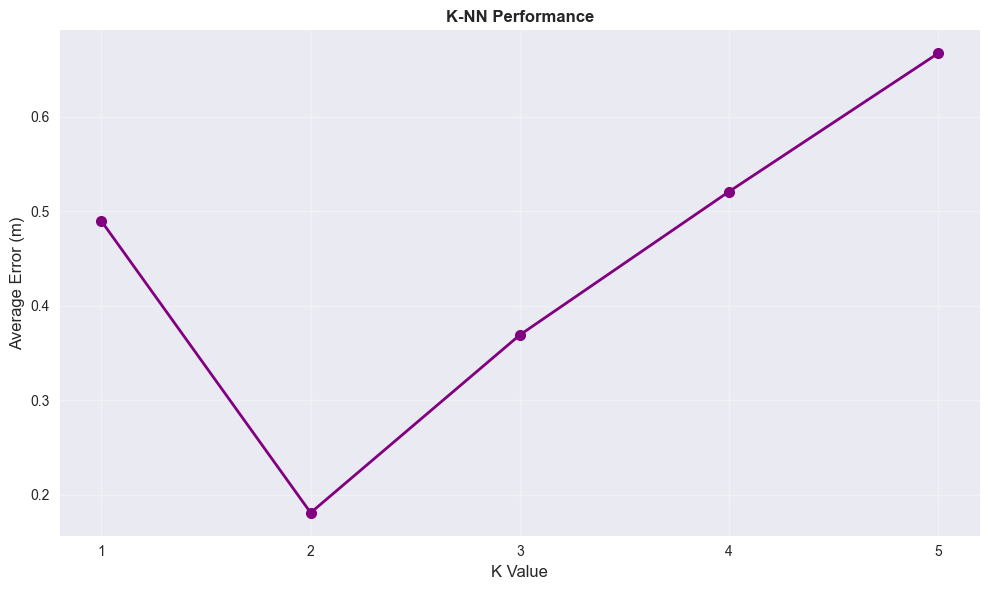

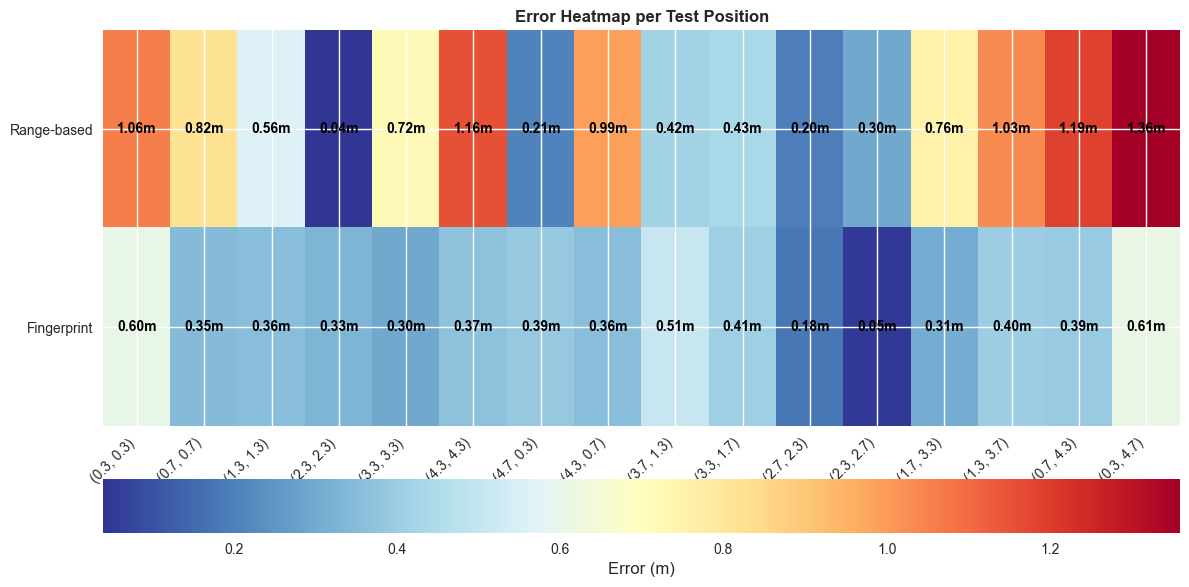

In [12]:
def create_comprehensive_visualization():
    """
    Buat 5 grafik terpisah untuk menampilkan hasil lokalisasi.
    """
    if not localization_system.evaluation_results:
        print("❌ Belum ada hasil evaluasi untuk divisualisasi.")
        return

    summary = localization_system.evaluation_results['summary']
    detailed_results = localization_system.evaluation_results['detailed']

    # --- 1. Error comparison chart ---
    fig1, ax1_ = plt.subplots(figsize=(10, 6))
    methods = ['Range-based', 'Fingerprint\n(k=1)', 'Fingerprint\n(k=2)',
               'Fingerprint\n(k=3)', 'Fingerprint\n(k=4)', 'Fingerprint\n(k=5)']
    errors = [
        summary['range_based_avg_error'],
        summary['fingerprint_avg_errors'].get(1, 0),
        summary['fingerprint_avg_errors'].get(2, 0),
        summary['fingerprint_avg_errors'].get(3, 0),
        summary['fingerprint_avg_errors'].get(4, 0),
        summary['fingerprint_avg_errors'].get(5, 0)
    ]
    colors = ['orange', 'lightblue', 'purple', 'darkblue', 'gray', 'brown']

    bars = ax1_.bar(methods, errors, color=colors, alpha=0.7, edgecolor='black')
    for bar, error in zip(bars, errors):
        height = bar.get_height()
        ax1_.text(bar.get_x() + bar.get_width() / 2., height + 0.02,
                  f'{error:.2f}m', ha='center', va='bottom', fontweight='bold')

    ax1_.set_ylabel('Average Error (m)', fontsize=12)
    ax1_.set_title('Algorithm Comparison', fontsize=12, fontweight='bold')
    ax1_.grid(True, alpha=0.3, axis='y')
    ax1_.axhline(y=1.12, color='red', linestyle='--', alpha=0.7, label='Paper Target (Range)')
    ax1_.axhline(y=0.44, color='green', linestyle='--', alpha=0.7, label='Paper Target (Fingerprint)')
    ax1_.legend(fontsize=8)
    fig1.tight_layout()

    # --- 2. Error distribution histogram ---
    fig2, ax2_ = plt.subplots(figsize=(10, 6))
    range_errors = [r['range_based']['error'] for r in detailed_results 
                    if r['range_based']['error'] != float('inf')]
    fp_errors = [r['fingerprint'][2]['error'] for r in detailed_results 
                 if r['fingerprint'][2]['error'] != float('inf')]

    ax2_.hist(range_errors, bins=10, alpha=0.7, label='Range-based', color='orange', edgecolor='black')
    ax2_.hist(fp_errors, bins=10, alpha=0.7, label='Fingerprint (k=2)', color='purple', edgecolor='black')
    ax2_.set_xlabel('Error (m)', fontsize=12)
    ax2_.set_ylabel('Frequency', fontsize=12)
    ax2_.set_title('Error Distribution (6 Nodes Systems)', fontsize=12, fontweight='bold')
    ax2_.legend()
    ax2_.grid(True, alpha=0.3)
    fig2.tight_layout()

    # --- 3. RSSI vs Distance ---
    fig3, ax3_ = plt.subplots(figsize=(10, 6))
    rssi_values = []
    distances = []

    for result in detailed_results:
        if result['range_based']['distances']:
            for distance in result['range_based']['distances']:
                rssi_calc = localization_system.signal_strength_1m - 10 * localization_system.path_loss_exponent * np.log10(distance)
                rssi_values.append(rssi_calc)
                distances.append(distance)

    ax3_.scatter(distances, rssi_values, alpha=0.6, color='blue', edgecolor='black')
    ax3_.set_xlabel('Distance (m)', fontsize=12)
    ax3_.set_ylabel('RSSI (dBm)', fontsize=12)
    ax3_.set_title('RSSI vs Distance Relationship', fontsize=12, fontweight='bold')
    ax3_.grid(True, alpha=0.3)
    theoretical_distances = np.linspace(0.1, 8, 100)
    theoretical_rssi = localization_system.signal_strength_1m - 10 * localization_system.path_loss_exponent * np.log10(theoretical_distances)
    ax3_.plot(theoretical_distances, theoretical_rssi, 'r--', linewidth=2, label='Theoretical Path Loss')
    ax3_.legend()
    fig3.tight_layout()

    # --- 4. K-value comparison ---
    fig4, ax4_ = plt.subplots(figsize=(10, 6))
    k_values = [1, 2, 3, 4, 5]
    k_errors = [summary['fingerprint_avg_errors'][k] for k in k_values]
    ax4_.plot(k_values, k_errors, 'o-', linewidth=2, markersize=8, color='purple')
    ax4_.set_xlabel('K Value', fontsize=12)
    ax4_.set_ylabel('Average Error (m)', fontsize=12)
    ax4_.set_title('K-NN Performance', fontsize=12, fontweight='bold')
    ax4_.grid(True, alpha=0.3)
    ax4_.set_xticks(k_values)
    fig4.tight_layout()

    # --- 5. Heatmap per position ---
    fig5, ax5_ = plt.subplots(figsize=(12, 6))
    error_data = []
    positions = []
    for result in detailed_results:
        pos = result['actual_position']
        range_err = result['range_based']['error'] if result['range_based']['error'] != float('inf') else 0
        fp_err = result['fingerprint'][3]['error'] if result['fingerprint'][3]['error'] != float('inf') else 0
        error_data.append([range_err, fp_err])
        positions.append(f"({pos[0]:.1f}, {pos[1]:.1f})")
        
    error_matrix = np.array(error_data).T
    im = ax5_.imshow(error_matrix, cmap='RdYlBu_r', aspect='auto')
    ax5_.set_yticks([0, 1])
    ax5_.set_yticklabels(['Range-based', 'Fingerprint'])
    ax5_.set_xticks(range(len(positions)))
    ax5_.set_xticklabels(positions, rotation=45, ha='right', fontsize=10)

    for i in range(error_matrix.shape[0]):
        for j in range(error_matrix.shape[1]):
            ax5_.text(j, i, f'{error_matrix[i, j]:.2f}m',
                      ha='center', va='center', color='black', fontweight='bold')
    
    ax5_.set_title('Error Heatmap per Test Position', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax5_, orientation='horizontal', pad=0.1)
    cbar.set_label('Error (m)', fontsize=12)
    fig5.tight_layout()

    # Tampilan summary performance di terminal
    summary_text = f"""
SISTEM PERFORMANCE SUMMARY:
• Range-based avg error: {summary['range_based_avg_error']:.2f}m
• Fingerprint avg error: {summary['fingerprint_avg_errors'][2]:.2f}m
• Improvement: {((summary['range_based_avg_error'] - summary['fingerprint_avg_errors'][2]) / summary['range_based_avg_error'] * 100):.1f}%
• Paper target achieved: {'V' if summary['fingerprint_avg_errors'][2] <= 0.44 else 'X'}
"""
    print(summary_text)
    plt.show()

# Generate comprehensive visualizations as 5 separate figures
create_comprehensive_visualization()


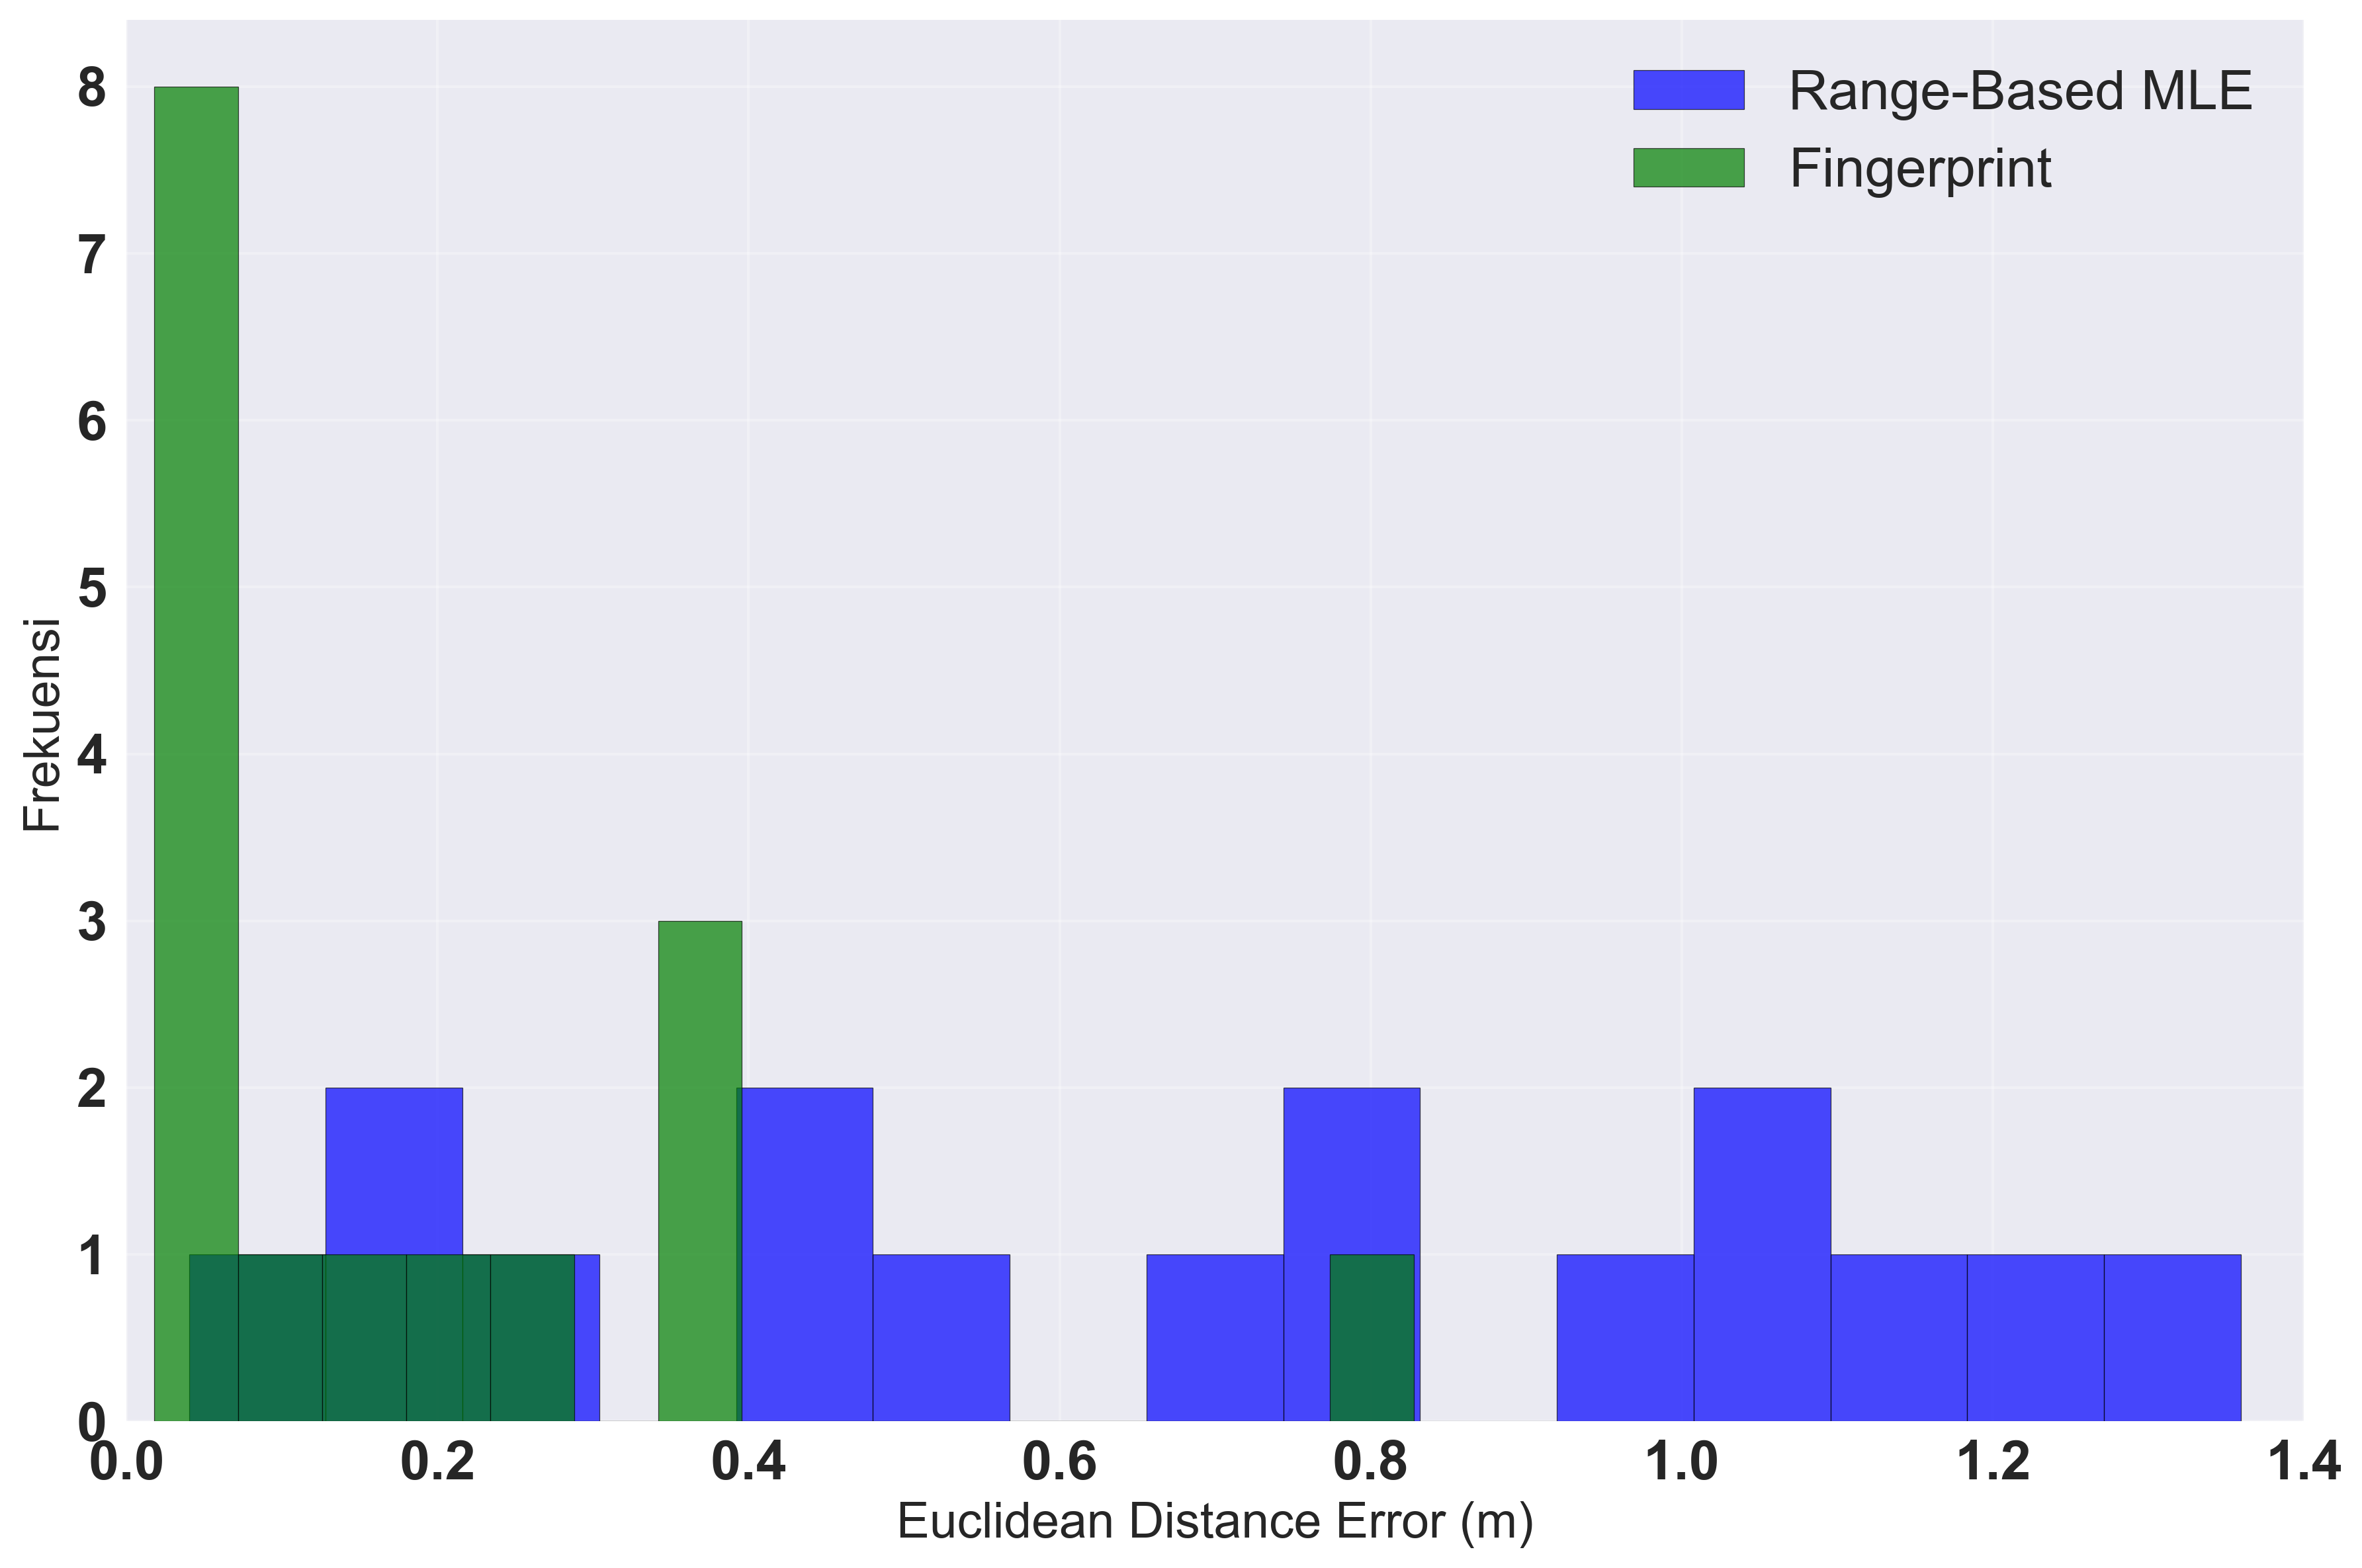

In [26]:
# =========================
# PLOT 7: Histogram Error Distribution (HANYA EUCLIDEAN DISTANCE)
# =========================
plt.figure(figsize=(12, 8), facecolor='white', dpi=300)

if len(rb_errors) > 0:
    plt.hist(rb_errors, bins=15, alpha=0.7, label="Range-Based MLE", 
             color='blue', edgecolor='black')
if len(fp_errors) > 0:
    plt.hist(fp_errors, bins=15, alpha=0.7, label="Fingerprint", 
             color='green', edgecolor='black')

plt.xlabel("Euclidean Distance Error (m)", fontsize=18)
plt.ylabel("Frekuensi", fontsize=18)

# Atur batas sumbu x dan y
plt.xlim(0, 1.4)

# Ticks yang sangat besar dan tebal
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


📦 Menggunakan dataset: testing_data  (jumlah titik: 16)
== RINGKASAN AKURASI ==
MAPE: Mean Absolute Percentage Error


,Algorithm,MAPE (%),Success Rate (%),MAE,RMSE,Median,P90,P95
0,Range-Based (MLE),34.20,100.0,0.703009,0.805996,0.742617,1.171317,1.229891
1,Fingerprint (kNN + IDW),7.79,100.0,0.180794,0.276089,0.078342,0.372201,0.499695



== HASIL PER TITIK ==


,gt_x,gt_y,gt_distance,rb_x,rb_y,rb_err,rb_rmse,fp_x,fp_y,fp_err,fp_conf,k_used
0,0.33,0.33,0.466690,1.193811,0.944708,1.060205,0.746605,0.499648,0.499648,0.239919,0.153153,2
1,4.66,0.33,4.671670,4.453738,0.344617,0.206779,0.837658,4.633443,0.366557,0.045185,0.133379,2
2,0.66,0.66,0.933381,1.247639,1.233410,0.821048,0.927261,0.678005,0.678005,0.025463,0.164276,2
3,4.33,0.66,4.380011,3.832764,1.515540,0.989541,0.964253,4.380129,0.619871,0.064213,0.128047,2
4,1.33,1.33,1.880904,1.838830,1.574400,0.564482,0.811256,1.317520,1.317520,0.017649,0.200354,2
5,3.66,1.33,3.894162,3.372525,1.635043,0.419158,0.809717,3.602875,1.397125,0.088142,0.133924,2
6,3.33,1.66,3.720820,2.984333,1.920799,0.433015,0.940096,3.000000,2.419284,0.827896,0.159936,2
7,2.33,2.33,3.295118,2.363675,2.351890,0.040164,0.952377,2.000000,2.538399,0.390295,0.269132,2
8,2.66,2.33,3.536170,2.736648,2.148933,0.196622,0.985775,3.000000,2.367950,0.342111,0.360627,2
9,2.33,2.66,3.536170,2.390538,2.369799,0.296448,0.926780,2.000000,2.531583,0.354106,0.239602,2


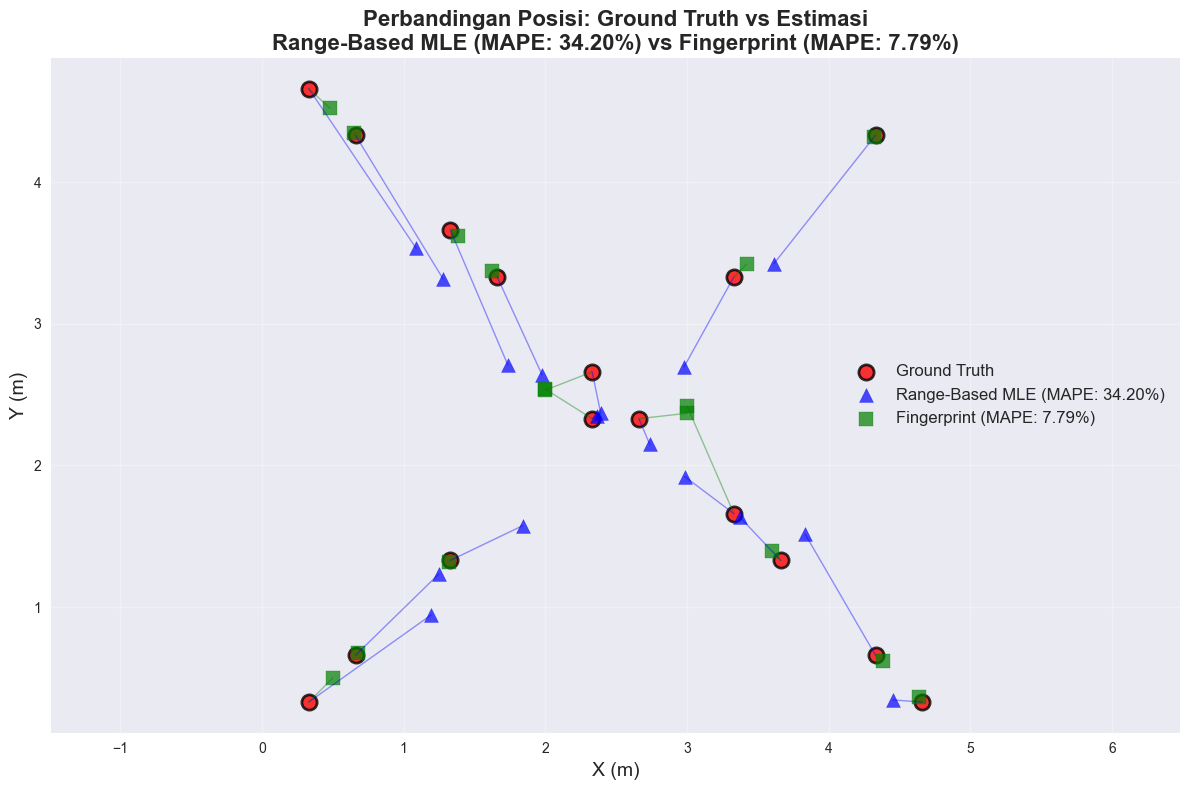

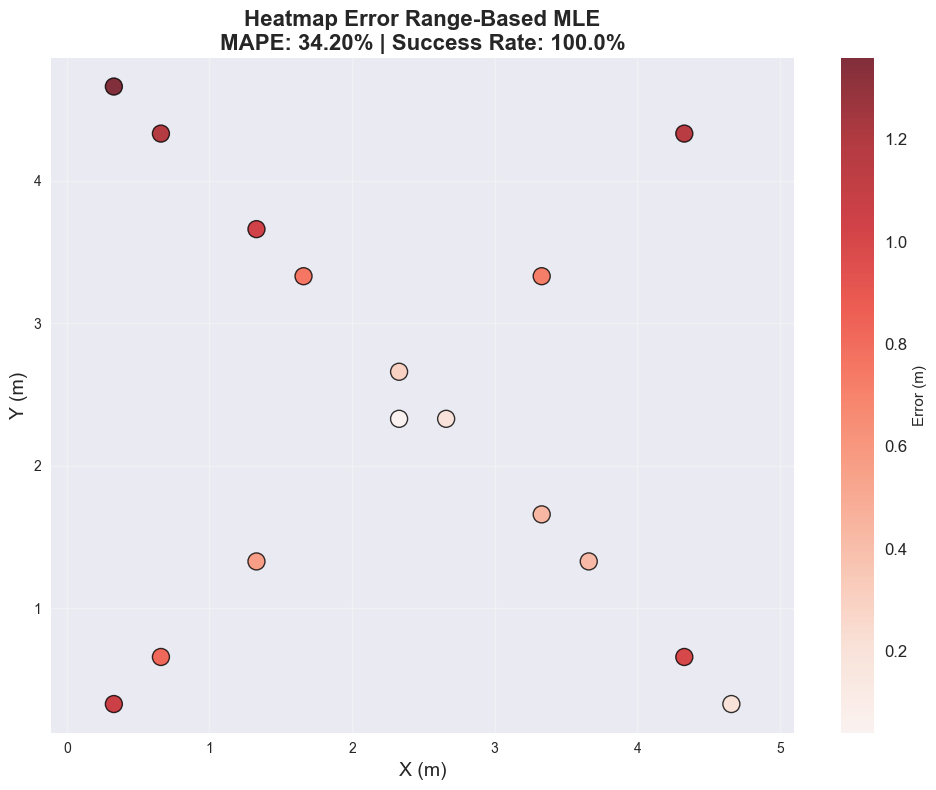

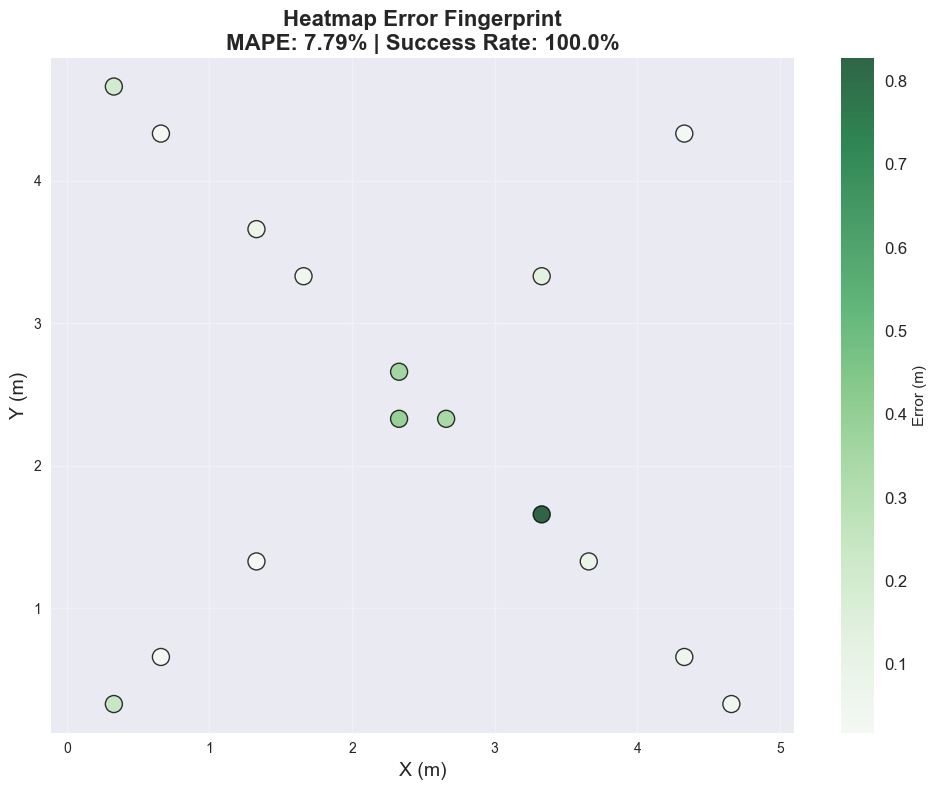

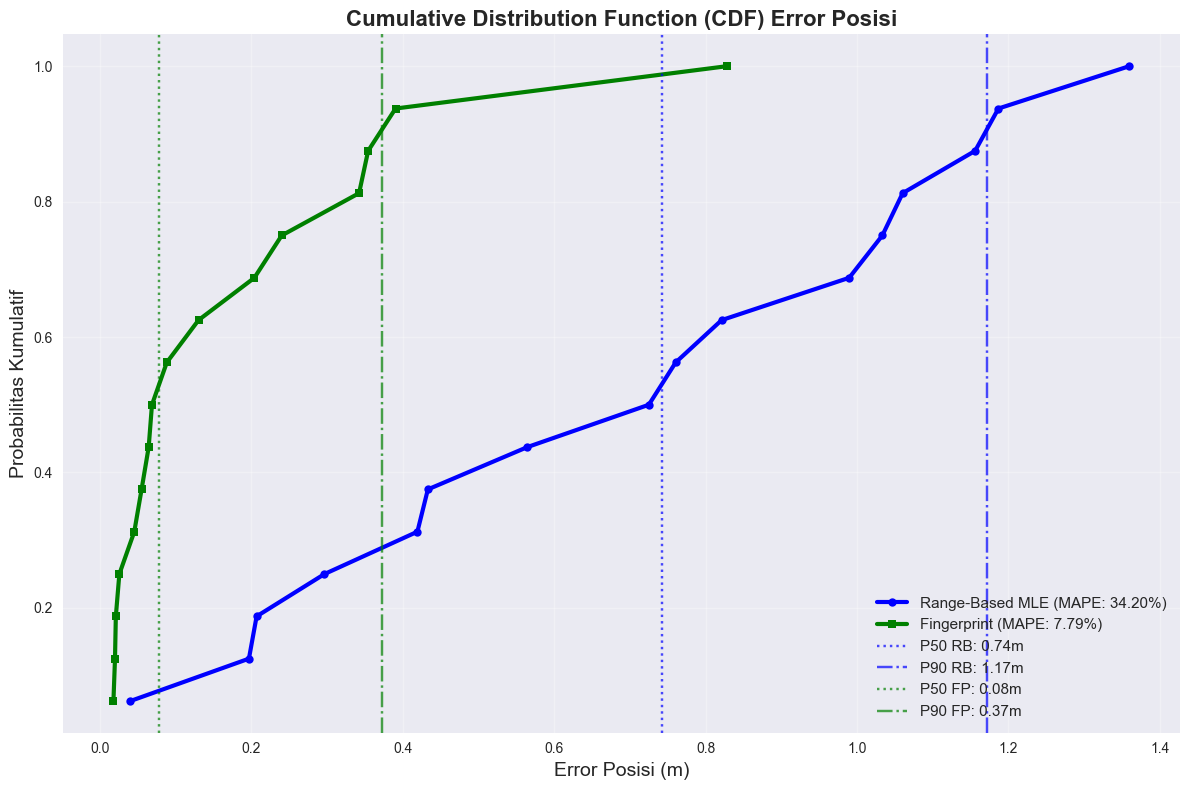

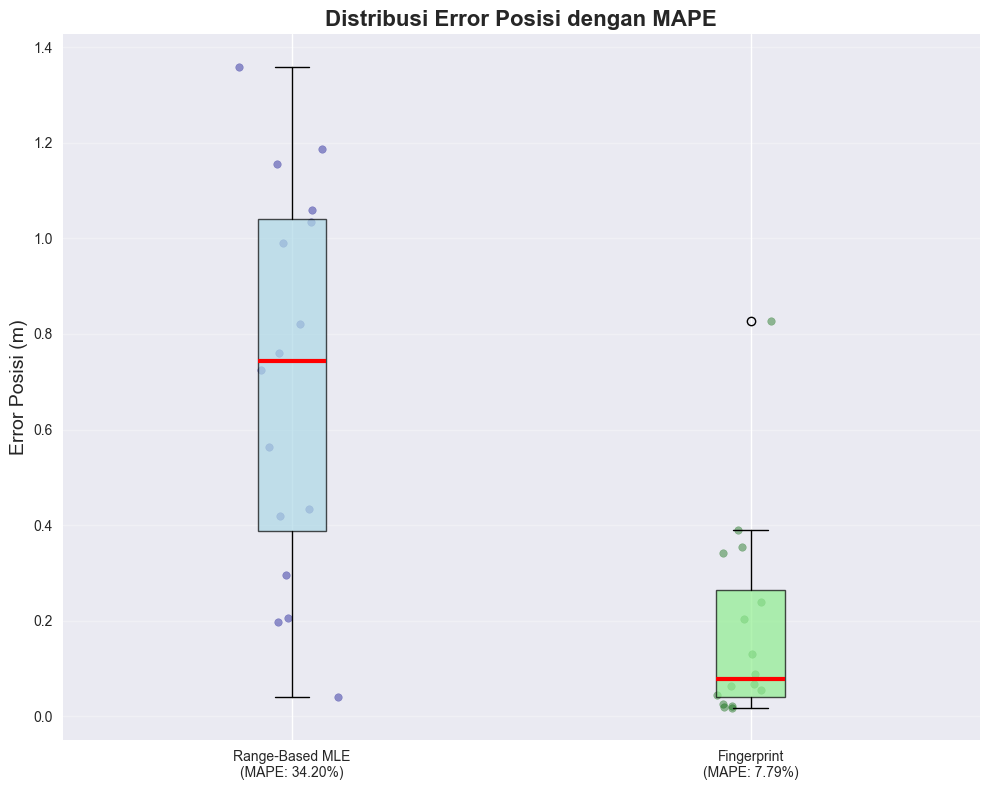

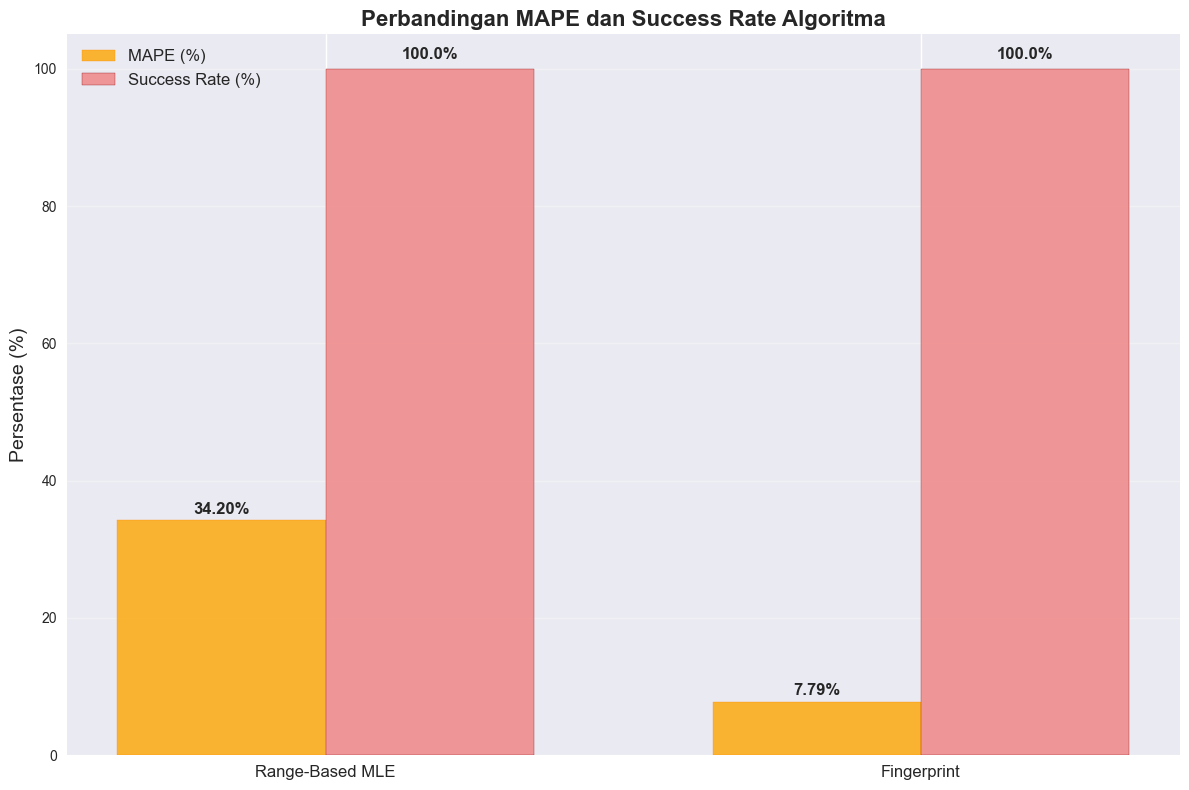

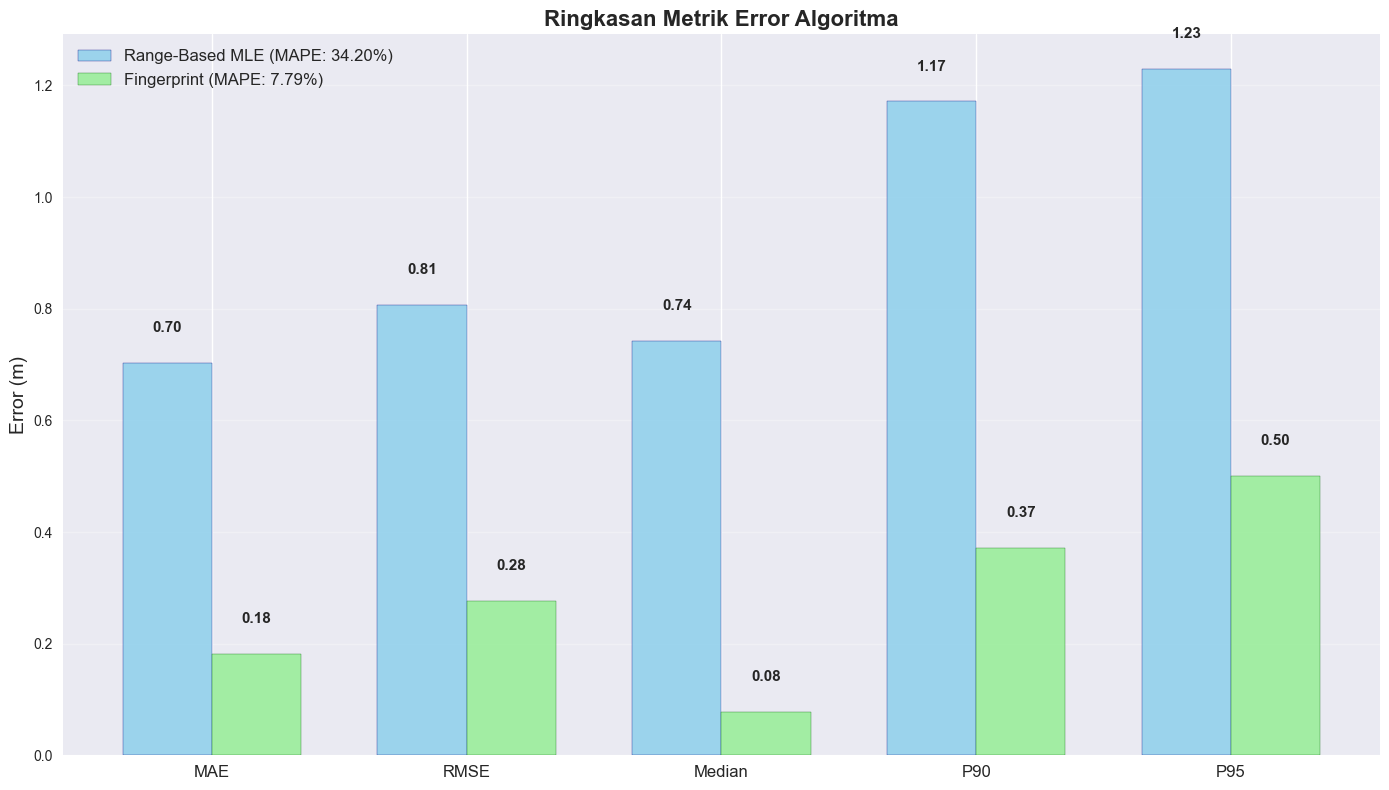

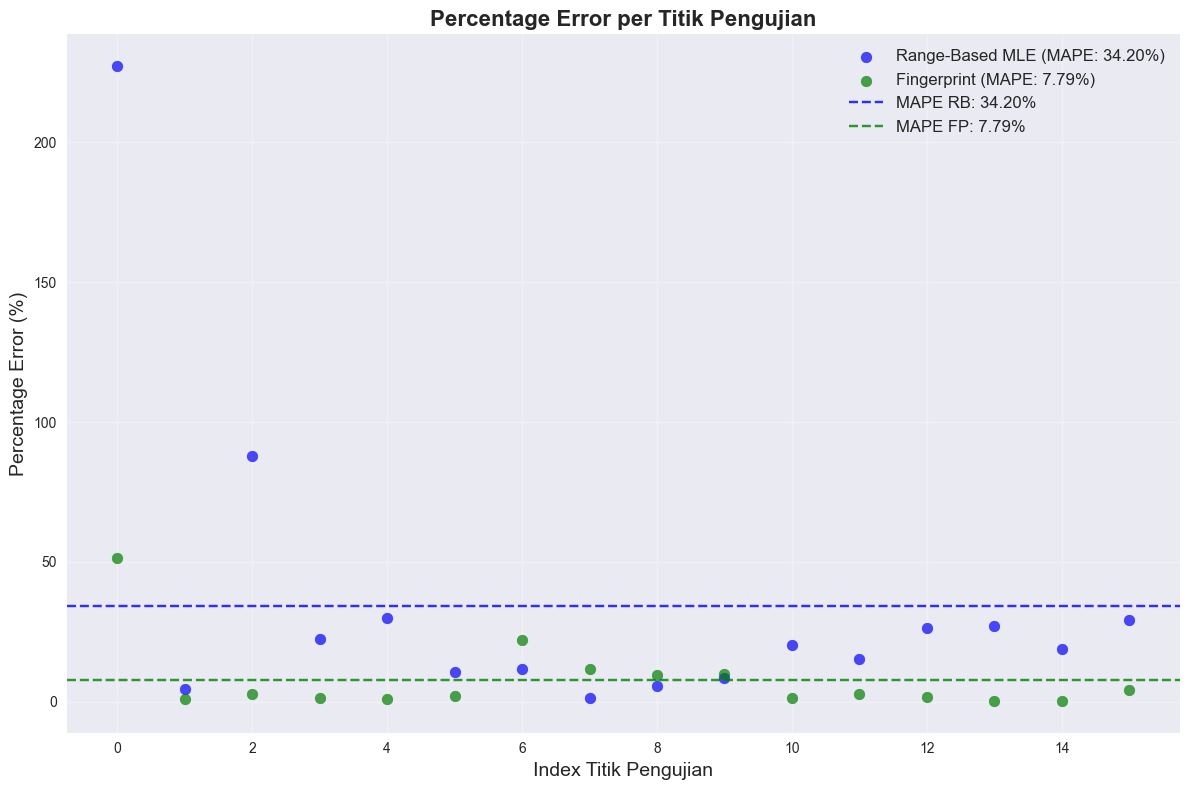

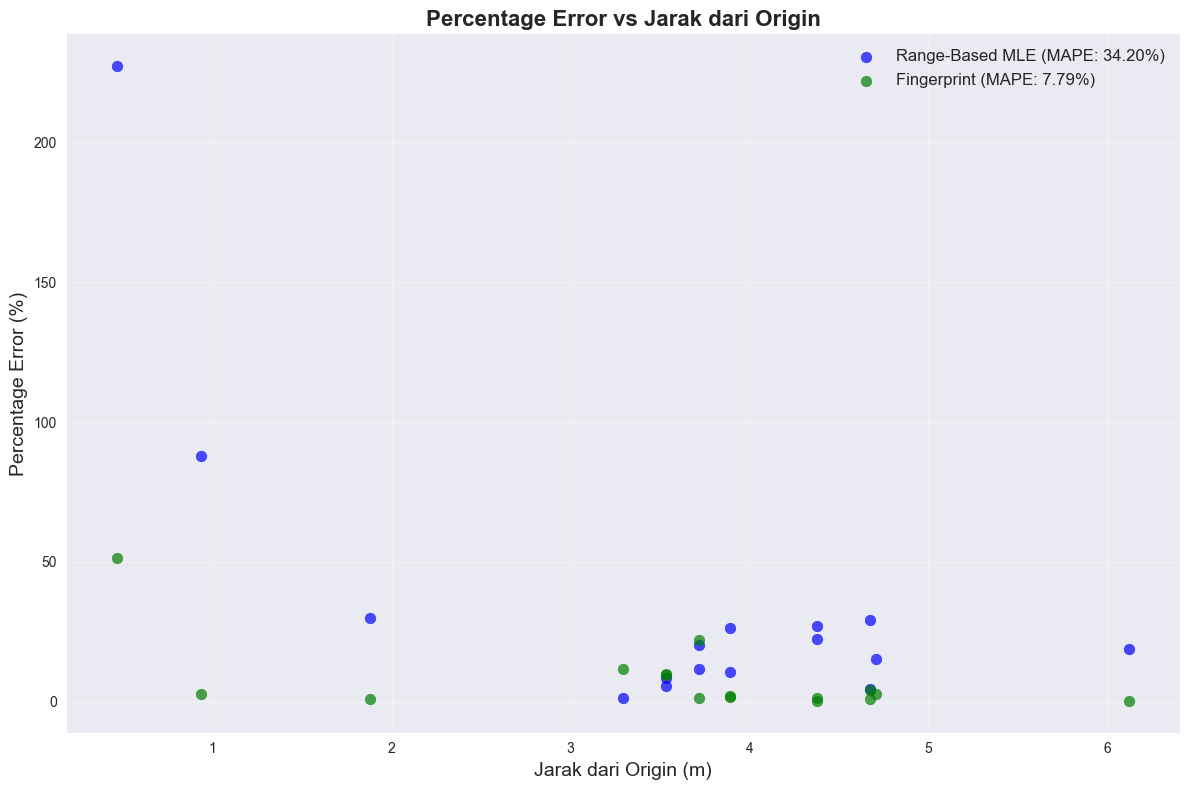


ANALISIS STATISTIK LANJUTAN
MAPE (Mean Absolute Percentage Error):
  Range-Based MLE: 34.20%
  Fingerprint: 7.79%

Success Rate:
  Range-Based MLE: 100.0%
  Fingerprint: 100.0%

Perbandingan Algoritma:
  MAE Improvement (FP vs RB): +74.3%
  MAPE Difference (FP vs RB): -26.40 percentage points

Interpretasi MAPE:
  Range-Based MLE: Cukup (34.20%)
  Fingerprint: Sangat Baik (7.79%)

Uji Statistik (t-test independen):
  t-statistic: 4.5345
  p-value: 0.0001
  Significant difference: Yes (α=0.05)
  Range-Based normalitas (p-value): 0.5703
  Fingerprint normalitas (p-value): 0.0007

Statistik Detail Range-Based MLE:
  Count: 16 titik
  Min Error: 0.040 m
  Max Error: 1.359 m
  Std Dev: 0.394 m
  CV (Coefficient of Variation): 56.08%

Statistik Detail Fingerprint:
  Count: 16 titik
  Min Error: 0.018 m
  Max Error: 0.828 m
  Std Dev: 0.209 m
  CV (Coefficient of Variation): 115.41%

RINGKASAN EVALUASI:
Dataset: 16 titik pengujian
K untuk Fingerprint: 2

Metrik Utama:
  Range-Based MLE - MAP

In [15]:
# =========================
# CELL: Evaluasi akurasi untuk SEMUA koordinat pengujian di notebook
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi yang lebih menarik
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# -- KONFIG --
K_FINGERPRINT = 2

# Cari otomatis calon variabel dataset pengujian yang berupa dict {(x,y): rssi}
CANDIDATES = ["testing_data", "testing_measurements", "test_measurements",
              "test_data", "uji_data", "uji_measurements"]

TEST_DICT = None
for name in CANDIDATES:
    if name in globals() and isinstance(globals()[name], dict):
        try:
            sample_key = next(iter(globals()[name].keys()))
            if isinstance(sample_key, tuple) and len(sample_key) == 2:
                TEST_DICT = globals()[name]
                print(f"📦 Menggunakan dataset: {name}  (jumlah titik: {len(TEST_DICT)})")
                break
        except StopIteration:
            pass

if TEST_DICT is None:
    raise RuntimeError(
        "Tidak menemukan dict koordinat pengujian. "
        "Buat/isi variabel dict seperti: testing_data = {(x,y): [[rssi_anchor...], ...], ...}"
    )

def euclid(a, b):
    ax, ay = a
    bx, by = b
    return float(np.hypot(ax - bx, ay - by))

# Proses evaluasi
rows = []
for (x_gt, y_gt), rssi_meas in TEST_DICT.items():
    # Range-Based MLE
    rb = localization_system.estimate_position_range_based(rssi_meas)
    rb_pos = tuple(rb["position"]) if rb["position"] is not None else (np.nan, np.nan)
    rb_err = euclid(rb_pos, (x_gt, y_gt)) if np.all(np.isfinite(rb_pos)) else np.nan
    rb_rmse = float(rb.get("error", np.nan))
    
    # Fingerprint kNN + inverse-distance
    fp = localization_system.estimate_position_fingerprint(rssi_meas, k=K_FINGERPRINT)
    fp_pos = tuple(fp["position"]) if fp["position"] is not None else (np.nan, np.nan)
    fp_err = euclid(fp_pos, (x_gt, y_gt)) if np.all(np.isfinite(fp_pos)) else np.nan
    fp_conf = float(fp.get("confidence", np.nan))
    
    # Hitung jarak euclidean dari origin untuk MAPE
    gt_distance = euclid((x_gt, y_gt), (0, 0))
    
    rows.append({
        "gt_x": x_gt, "gt_y": y_gt,
        "gt_distance": gt_distance,
        "rb_x": rb_pos[0] if rb["position"] is not None else np.nan,
        "rb_y": rb_pos[1] if rb["position"] is not None else np.nan,
        "rb_err": rb_err,
        "rb_rmse": rb_rmse,
        "fp_x": fp_pos[0] if fp["position"] is not None else np.nan,
        "fp_y": fp_pos[1] if fp["position"] is not None else np.nan,
        "fp_err": fp_err,
        "fp_conf": fp_conf,
        "k_used": K_FINGERPRINT,
    })

results = pd.DataFrame(rows).sort_values(by=["gt_y","gt_x"]).reset_index(drop=True)

def summarize(errs):
    errs = np.asarray([e for e in errs if np.isfinite(e)])
    if errs.size == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "Median": np.nan, "P90": np.nan, "P95": np.nan}
    return {
        "MAE": float(np.mean(np.abs(errs))),
        "RMSE": float(np.sqrt(np.mean(errs**2))),
        "Median": float(np.percentile(errs, 50)),
        "P90": float(np.percentile(errs, 90)),
        "P95": float(np.percentile(errs, 95)),
    }

# Hitung MAPE (Mean Absolute Percentage Error)
def calculate_mape(errors, true_distances):
    valid_indices = [i for i, (e, d) in enumerate(zip(errors, true_distances)) 
                    if np.isfinite(e) and np.isfinite(d) and d > 0]
    
    if not valid_indices:
        return np.nan
    
    valid_errors = [errors[i] for i in valid_indices]
    valid_distances = [true_distances[i] for i in valid_indices]
    
    percentage_errors = [abs(e) / d * 100 for e, d in zip(valid_errors, valid_distances)]
    return float(np.mean(percentage_errors))

rb_sum = summarize(results["rb_err"].values)
fp_sum = summarize(results["fp_err"].values)

# Hitung MAPE
rb_mape = calculate_mape(results["rb_err"].values, results["gt_distance"].values)
fp_mape = calculate_mape(results["fp_err"].values, results["gt_distance"].values)

# Hitung success rate (berhasil memberikan estimasi)
rb_success_rate = (len(results.dropna(subset=['rb_err'])) / len(results)) * 100
fp_success_rate = (len(results.dropna(subset=['fp_err'])) / len(results)) * 100

summary = pd.DataFrame([
    {"Algorithm": "Range-Based (MLE)", "MAPE (%)": f"{rb_mape:.2f}", 
     "Success Rate (%)": f"{rb_success_rate:.1f}", **rb_sum},
    {"Algorithm": "Fingerprint (kNN + IDW)", "MAPE (%)": f"{fp_mape:.2f}", 
     "Success Rate (%)": f"{fp_success_rate:.1f}", **fp_sum},
])

print("== RINGKASAN AKURASI ==")
print("MAPE: Mean Absolute Percentage Error")
display(summary)
print("\n== HASIL PER TITIK ==")
display(results)

# =========================
# PLOT 1: Perbandingan Posisi Ground Truth vs Estimasi
# =========================
plt.figure(figsize=(12, 8))
plt.scatter(results["gt_x"], results["gt_y"], s=120, marker='o', 
           label="Ground Truth", color='red', alpha=0.8, edgecolors='black', linewidth=2)
plt.scatter(results["rb_x"], results["rb_y"], s=100, marker='^', 
           label=f"Range-Based MLE (MAPE: {rb_mape:.2f}%)", color='blue', alpha=0.7)
plt.scatter(results["fp_x"], results["fp_y"], s=100, marker='s', 
           label=f"Fingerprint (MAPE: {fp_mape:.2f}%)", color='green', alpha=0.7)

# Tambahkan garis error
for _, r in results.iterrows():
    if np.isfinite(r["rb_x"]) and np.isfinite(r["rb_y"]):
        plt.plot([r["gt_x"], r["rb_x"]], [r["gt_y"], r["rb_y"]], 
                'b-', alpha=0.4, linewidth=1)
    if np.isfinite(r["fp_x"]) and np.isfinite(r["fp_y"]):
        plt.plot([r["gt_x"], r["fp_x"]], [r["gt_y"], r["fp_y"]], 
                'g-', alpha=0.4, linewidth=1)

plt.xlabel("X (m)", fontsize=14)
plt.ylabel("Y (m)", fontsize=14)
plt.title("Perbandingan Posisi: Ground Truth vs Estimasi\n" + 
          f"Range-Based MLE (MAPE: {rb_mape:.2f}%) vs Fingerprint (MAPE: {fp_mape:.2f}%)",
          fontsize=16, fontweight='bold')
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: Heatmap Error Range-Based
# =========================
plt.figure(figsize=(10, 8))
valid_rb = results.dropna(subset=['rb_err'])
if not valid_rb.empty:
    scatter = plt.scatter(valid_rb["gt_x"], valid_rb["gt_y"], 
                         c=valid_rb["rb_err"], s=150, cmap='Reds', 
                         alpha=0.8, edgecolors='black', linewidth=1)
    cbar = plt.colorbar(scatter, label='Error (m)')
    cbar.ax.tick_params(labelsize=12)

plt.xlabel("X (m)", fontsize=14)
plt.ylabel("Y (m)", fontsize=14)
plt.title(f"Heatmap Error Range-Based MLE\nMAPE: {rb_mape:.2f}% | " +
          f"Success Rate: {rb_success_rate:.1f}%", fontsize=16, fontweight='bold')
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# PLOT 3: Heatmap Error Fingerprint
# =========================
plt.figure(figsize=(10, 8))
valid_fp = results.dropna(subset=['fp_err'])
if not valid_fp.empty:
    scatter = plt.scatter(valid_fp["gt_x"], valid_fp["gt_y"], 
                         c=valid_fp["fp_err"], s=150, cmap='Greens', 
                         alpha=0.8, edgecolors='black', linewidth=1)
    cbar = plt.colorbar(scatter, label='Error (m)')
    cbar.ax.tick_params(labelsize=12)

plt.xlabel("X (m)", fontsize=14)
plt.ylabel("Y (m)", fontsize=14)
plt.title(f"Heatmap Error Fingerprint\nMAPE: {fp_mape:.2f}% | " +
          f"Success Rate: {fp_success_rate:.1f}%", fontsize=16, fontweight='bold')
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# PLOT 4: CDF Error Posisi
# =========================
def _ecdf(data: np.ndarray):
    x = np.sort(data[np.isfinite(data)])
    y = np.arange(1, x.size + 1) / x.size if x.size else np.array([])
    return x, y

plt.figure(figsize=(12, 8))
x_rb, y_rb = _ecdf(results["rb_err"].values)
x_fp, y_fp = _ecdf(results["fp_err"].values)

plt.plot(x_rb, y_rb, linewidth=3, label=f"Range-Based MLE (MAPE: {rb_mape:.2f}%)", 
         marker='o', markersize=6, color='blue')
plt.plot(x_fp, y_fp, linewidth=3, label=f"Fingerprint (MAPE: {fp_mape:.2f}%)", 
         marker='s', markersize=6, color='green')

# Tambahkan garis percentile penting
if len(x_rb) > 0:
    p50_rb = np.percentile(x_rb, 50)
    p90_rb = np.percentile(x_rb, 90)
    plt.axvline(p50_rb, color='blue', linestyle=':', alpha=0.7, 
               label=f'P50 RB: {p50_rb:.2f}m')
    plt.axvline(p90_rb, color='blue', linestyle='-.', alpha=0.7, 
               label=f'P90 RB: {p90_rb:.2f}m')

if len(x_fp) > 0:
    p50_fp = np.percentile(x_fp, 50)
    p90_fp = np.percentile(x_fp, 90)
    plt.axvline(p50_fp, color='green', linestyle=':', alpha=0.7, 
               label=f'P50 FP: {p50_fp:.2f}m')
    plt.axvline(p90_fp, color='green', linestyle='-.', alpha=0.7, 
               label=f'P90 FP: {p90_fp:.2f}m')

plt.xlabel("Error Posisi (m)", fontsize=14)
plt.ylabel("Probabilitas Kumulatif", fontsize=14)
plt.title("Cumulative Distribution Function (CDF) Error Posisi", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

# =========================
# PLOT 5: Box Plot Perbandingan Error
# =========================
plt.figure(figsize=(10, 8))
error_data = []
labels = []
colors = []

rb_errors = results["rb_err"].dropna().values
fp_errors = results["fp_err"].dropna().values

if len(rb_errors) > 0:
    error_data.append(rb_errors)
    labels.append(f"Range-Based MLE\n(MAPE: {rb_mape:.2f}%)")
    colors.append('lightblue')
if len(fp_errors) > 0:
    error_data.append(fp_errors)
    labels.append(f"Fingerprint\n(MAPE: {fp_mape:.2f}%)")
    colors.append('lightgreen')

if error_data:
    box_plot = plt.boxplot(error_data, labels=labels, patch_artist=True,
                          boxprops=dict(alpha=0.7),
                          medianprops=dict(color='red', linewidth=3))
    
    # Warnai box
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    # Tambahkan scatter points untuk semua data
    for i, data in enumerate(error_data):
        y = data
        x = np.random.normal(i+1, 0.04, size=len(y))
        plt.scatter(x, y, alpha=0.4, s=30, color='darkblue' if i == 0 else 'darkgreen')

plt.ylabel("Error Posisi (m)", fontsize=14)
plt.title("Distribusi Error Posisi dengan MAPE", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# =========================
# PLOT 6: Bar Chart MAPE dan Success Rate
# =========================
plt.figure(figsize=(12, 8))
algorithms = ['Range-Based MLE', 'Fingerprint']
mape_values = [rb_mape, fp_mape]
success_values = [rb_success_rate, fp_success_rate]

x_pos = np.arange(len(algorithms))
width = 0.35

bars1 = plt.bar(x_pos - width/2, mape_values, width, 
               label='MAPE (%)', 
               color='orange', alpha=0.8, edgecolor='darkorange')
bars2 = plt.bar(x_pos + width/2, success_values, width, 
               label='Success Rate (%)', 
               color='lightcoral', alpha=0.8, edgecolor='darkred')

# Tambahkan nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(x_pos, algorithms, fontsize=12)
plt.ylabel("Persentase (%)", fontsize=14)
plt.title("Perbandingan MAPE dan Success Rate Algoritma", fontsize=16, fontweight='bold')
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# PLOT 8: Ringkasan Metrik
# =========================
plt.figure(figsize=(14, 8))
metrics = ["MAE", "RMSE", "Median", "P90", "P95"]
rb_values = [rb_sum.get(m, 0) for m in metrics]
fp_values = [fp_sum.get(m, 0) for m in metrics]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x_pos - width/2, rb_values, width, 
               label=f"Range-Based MLE (MAPE: {rb_mape:.2f}%)", 
               color='skyblue', alpha=0.8, edgecolor='navy')
bars2 = plt.bar(x_pos + width/2, fp_values, width, 
               label=f"Fingerprint (MAPE: {fp_mape:.2f}%)", 
               color='lightgreen', alpha=0.8, edgecolor='darkgreen')

# Tambahkan nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(x_pos, metrics, fontsize=12)
plt.ylabel("Error (m)", fontsize=14)
plt.title("Ringkasan Metrik Error Algoritma", fontsize=16, fontweight='bold')
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# PLOT 9: MAPE Visualization (Tambahan)
# =========================
plt.figure(figsize=(12, 8))

# Hitung percentage error untuk setiap titik
rb_percentage_errors = []
fp_percentage_errors = []

for _, row in results.iterrows():
    if np.isfinite(row['rb_err']) and row['gt_distance'] > 0:
        rb_pe = (row['rb_err'] / row['gt_distance']) * 100
        rb_percentage_errors.append(rb_pe)
    
    if np.isfinite(row['fp_err']) and row['gt_distance'] > 0:
        fp_pe = (row['fp_err'] / row['gt_distance']) * 100
        fp_percentage_errors.append(fp_pe)

# Plot scatter percentage errors
if rb_percentage_errors:
    valid_rb_data = results.dropna(subset=['rb_err'])
    valid_rb_pe = [(row['rb_err'] / row['gt_distance']) * 100 
                   for _, row in valid_rb_data.iterrows() if row['gt_distance'] > 0]
    
    if len(valid_rb_pe) > 0:
        plt.scatter(range(len(valid_rb_pe)), valid_rb_pe, 
                   alpha=0.7, s=60, color='blue', label=f'Range-Based MLE (MAPE: {rb_mape:.2f}%)')

if fp_percentage_errors:
    valid_fp_data = results.dropna(subset=['fp_err'])
    valid_fp_pe = [(row['fp_err'] / row['gt_distance']) * 100 
                   for _, row in valid_fp_data.iterrows() if row['gt_distance'] > 0]
    
    if len(valid_fp_pe) > 0:
        plt.scatter(range(len(valid_fp_pe)), valid_fp_pe, 
                   alpha=0.7, s=60, color='green', label=f'Fingerprint (MAPE: {fp_mape:.2f}%)')

# Tambahkan garis MAPE
if not np.isnan(rb_mape):
    plt.axhline(rb_mape, color='blue', linestyle='--', alpha=0.8, 
               label=f'MAPE RB: {rb_mape:.2f}%')
if not np.isnan(fp_mape):
    plt.axhline(fp_mape, color='green', linestyle='--', alpha=0.8, 
               label=f'MAPE FP: {fp_mape:.2f}%')

plt.xlabel("Index Titik Pengujian", fontsize=14)
plt.ylabel("Percentage Error (%)", fontsize=14)
plt.title("Percentage Error per Titik Pengujian", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# PLOT 10: Perbandingan MAPE vs Distance
# =========================
plt.figure(figsize=(12, 8))

# Plot MAPE vs distance untuk Range-Based
rb_valid = results.dropna(subset=['rb_err'])
if not rb_valid.empty:
    rb_pe_values = [(row['rb_err'] / row['gt_distance']) * 100 
                    for _, row in rb_valid.iterrows() if row['gt_distance'] > 0]
    rb_distances = [row['gt_distance'] for _, row in rb_valid.iterrows() if row['gt_distance'] > 0]
    
    if rb_pe_values:
        plt.scatter(rb_distances, rb_pe_values, alpha=0.7, s=60, color='blue', 
                   label=f'Range-Based MLE (MAPE: {rb_mape:.2f}%)')

# Plot MAPE vs distance untuk Fingerprint
fp_valid = results.dropna(subset=['fp_err'])
if not fp_valid.empty:
    fp_pe_values = [(row['fp_err'] / row['gt_distance']) * 100 
                    for _, row in fp_valid.iterrows() if row['gt_distance'] > 0]
    fp_distances = [row['gt_distance'] for _, row in fp_valid.iterrows() if row['gt_distance'] > 0]
    
    if fp_pe_values:
        plt.scatter(fp_distances, fp_pe_values, alpha=0.7, s=60, color='green', 
                   label=f'Fingerprint (MAPE: {fp_mape:.2f}%)')

plt.xlabel("Jarak dari Origin (m)", fontsize=14)
plt.ylabel("Percentage Error (%)", fontsize=14)
plt.title("Percentage Error vs Jarak dari Origin", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# Analisis Statistik Lanjutan
# =========================
print("\n" + "="*80)
print("ANALISIS STATISTIK LANJUTAN")
print("="*80)

print(f"MAPE (Mean Absolute Percentage Error):")
print(f"  Range-Based MLE: {rb_mape:.2f}%")
print(f"  Fingerprint: {fp_mape:.2f}%")

print(f"\nSuccess Rate:")
print(f"  Range-Based MLE: {rb_success_rate:.1f}%")
print(f"  Fingerprint: {fp_success_rate:.1f}%")

# Improvement analysis
if len(rb_errors) > 0 and len(fp_errors) > 0:
    mae_improvement = (rb_sum['MAE'] - fp_sum['MAE']) / rb_sum['MAE'] * 100
    mape_diff = fp_mape - rb_mape
    
    print(f"\nPerbandingan Algoritma:")
    print(f"  MAE Improvement (FP vs RB): {mae_improvement:+.1f}%")
    print(f"  MAPE Difference (FP vs RB): {mape_diff:+.2f} percentage points")
    
    # Interpretasi MAPE
    def interpret_mape(mape_value):
        if np.isnan(mape_value):
            return "N/A"
        elif mape_value < 10:
            return "Sangat Baik"
        elif mape_value < 20:
            return "Baik"
        elif mape_value < 50:
            return "Cukup"
        else:
            return "Kurang Baik"
    
    print(f"\nInterpretasi MAPE:")
    print(f"  Range-Based MLE: {interpret_mape(rb_mape)} ({rb_mape:.2f}%)")
    print(f"  Fingerprint: {interpret_mape(fp_mape)} ({fp_mape:.2f}%)")
    
    # Statistical significance test
    try:
        from scipy import stats
        
        # Uji perbedaan rata-rata error
        if len(rb_errors) > 1 and len(fp_errors) > 1:
            statistic, p_value = stats.ttest_ind(rb_errors, fp_errors)
            print(f"\nUji Statistik (t-test independen):")
            print(f"  t-statistic: {statistic:.4f}")
            print(f"  p-value: {p_value:.4f}")
            print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")
            
        # Uji normalitas
        if len(rb_errors) > 3:
            _, rb_normal_p = stats.shapiro(rb_errors[:50])  # Maksimal 50 sampel untuk Shapiro-Wilk
            print(f"  Range-Based normalitas (p-value): {rb_normal_p:.4f}")
            
        if len(fp_errors) > 3:
            _, fp_normal_p = stats.shapiro(fp_errors[:50])
            print(f"  Fingerprint normalitas (p-value): {fp_normal_p:.4f}")
            
    except ImportError:
        print("\n  Statistical test: scipy not available")
    except Exception as e:
        print(f"\n  Statistical test error: {str(e)}")

# Statistik tambahan per algoritma
print(f"\nStatistik Detail Range-Based MLE:")
if len(rb_errors) > 0:
    print(f"  Count: {len(rb_errors)} titik")
    print(f"  Min Error: {np.min(rb_errors):.3f} m")
    print(f"  Max Error: {np.max(rb_errors):.3f} m")
    print(f"  Std Dev: {np.std(rb_errors):.3f} m")
    print(f"  CV (Coefficient of Variation): {(np.std(rb_errors)/np.mean(rb_errors)*100):.2f}%")

print(f"\nStatistik Detail Fingerprint:")
if len(fp_errors) > 0:
    print(f"  Count: {len(fp_errors)} titik")
    print(f"  Min Error: {np.min(fp_errors):.3f} m")
    print(f"  Max Error: {np.max(fp_errors):.3f} m")
    print(f"  Std Dev: {np.std(fp_errors):.3f} m")
    print(f"  CV (Coefficient of Variation): {(np.std(fp_errors)/np.mean(fp_errors)*100):.2f}%")

print("\n" + "="*80)

# Ringkasan Final
print("RINGKASAN EVALUASI:")
print("="*80)
print(f"Dataset: {len(TEST_DICT)} titik pengujian")
print(f"K untuk Fingerprint: {K_FINGERPRINT}")
print()
print("Metrik Utama:")
print(f"  Range-Based MLE - MAPE: {rb_mape:.2f}%, MAE: {rb_sum.get('MAE', 0):.3f}m, Success: {rb_success_rate:.1f}%")
print(f"  Fingerprint     - MAPE: {fp_mape:.2f}%, MAE: {fp_sum.get('MAE', 0):.3f}m, Success: {fp_success_rate:.1f}%")
print()

# Rekomendasi berdasarkan hasil
if not np.isnan(rb_mape) and not np.isnan(fp_mape):
    if fp_mape < rb_mape:
        better_alg = "Fingerprint"
        improvement = rb_mape - fp_mape
    else:
        better_alg = "Range-Based MLE"
        improvement = fp_mape - rb_mape
    
    print(f"Rekomendasi: {better_alg} menunjukkan performa lebih baik")
    print(f"Selisih MAPE: {improvement:.2f} percentage points")
else:
    print("Rekomendasi: Tidak dapat ditentukan karena data tidak lengkap")

print("="*80)

## Pickle

In [12]:
# Prasyarat dari notebook kamu:
# - training_data: dict[(x,y)] -> list of samples
#   Tiap sample = list RSSI (dBm) panjang N_anchor

import numpy as np
import pandas as pd
from pathlib import Path
import pickle

OUT_DIR = Path("./models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# ============================================================
# Fingerprint .pkl (sesuai logika CELL 4 + agregasi CSV _sN)
# ============================================================

from __future__ import annotations
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple, Any, Iterable, Callable

import numpy as np
import pandas as pd
import pickle
import cloudpickle  # type: ignore

# ---------- Model fingerprint: build DB (mean per anchor), KNN, weighted average ----------
@dataclass
class FingerprintNotebookStyleModel:
    """
    Replikasi logika CELL 4:
      - build_fingerprint_database(training_data): rata-rata per anchor (mean) untuk tiap lokasi
      - euclidean_distance
      - k_nearest_neighbors(k)
      - weighted_average_estimation(k): bobot 1/(d + 0.001)
      - estimate_position_fingerprint(target_rssi, k): terima list atau list-of-lists (di-mean per anchor)
    Tambahan:
      - predict_from_file(csv, aggregate="auto"): gabungkan sample_id berprefix '_sN' menjadi satu scan
    """
    fingerprint_database: Dict[Tuple[float, float], Dict[str, Any]] = field(default_factory=dict)
    database_locations: List[Tuple[float, float]] = field(default_factory=list)
    database_fingerprints: List[List[float]] = field(default_factory=list)
    default_k: int = 2  # pilih default k=2 sesuai evaluasi kamu
    eps: float = 1e-3

    # ---------- BUILD DB ----------
    def build_fingerprint_database(self, training_data: Dict[Tuple[float,float], List[List[float]]]) -> None:
        self.fingerprint_database.clear()
        self.database_locations.clear()
        self.database_fingerprints.clear()

        for location, rssi_measurements in training_data.items():
            if isinstance(rssi_measurements, list) and len(rssi_measurements) > 0 and isinstance(rssi_measurements[0], (list, tuple, np.ndarray)):
                arr = np.asarray(rssi_measurements, dtype=float)   # [Nsamp, Nanchor]
                avg_fingerprint = np.mean(arr, axis=0).tolist()    # CELL 4 memakai mean
                std_fingerprint = np.std(arr, axis=0).tolist()
                info = {
                    "avg_rssi": avg_fingerprint,
                    "std_rssi": std_fingerprint,
                    "raw_measurements": [list(map(float, v)) for v in rssi_measurements],
                    "num_measurements": int(arr.shape[0]),
                }
            else:
                vec = np.asarray(rssi_measurements, dtype=float).tolist()
                info = {
                    "avg_rssi": vec,
                    "std_rssi": [0.0] * len(vec),
                    "raw_measurements": [vec],
                    "num_measurements": 1,
                }
                avg_fingerprint = vec

            self.fingerprint_database[location] = info
            self.database_locations.append(location)
            self.database_fingerprints.append(avg_fingerprint)

    # ---------- CORE METHODS ----------
    @staticmethod
    def euclidean_distance(f1: List[float], f2: List[float]) -> float:
        a = np.asarray(f1, float)
        b = np.asarray(f2, float)
        L = min(len(a), len(b))
        a = a[:L]; b = b[:L]
        # Abaikan NaN jika ada (robust)
        mask = (~np.isnan(a)) & (~np.isnan(b))
        if not np.any(mask):
            return float("inf")
        return float(np.sqrt(np.mean((a[mask] - b[mask])**2)))

    def k_nearest_neighbors(self, target_fingerprint: List[float], k: int = None):
        if not self.database_fingerprints:
            raise ValueError("Fingerprint DB kosong. Panggil build_fingerprint_database() dulu.")
        if k is None:
            k = self.default_k
        dists = []
        for i, db_fp in enumerate(self.database_fingerprints):
            d = self.euclidean_distance(target_fingerprint, db_fp)
            dists.append((i, d))
        dists.sort(key=lambda x: x[1])
        idx = [i for i, _ in dists[:k]]
        dd  = [d for _, d in dists[:k]]
        return idx, dd

    def weighted_average_estimation(self, target_fingerprint, k=None):
        if k is None:
            k = self.default_k
        idx, dd = self.k_nearest_neighbors(target_fingerprint, k)

        # Tetap early return posisi untuk akurasi numerik,
        # tapi konsistenkan definisi confidence.
        if dd and dd[0] < self.eps:
            pos = self.database_locations[idx[0]]
            conf = 1.0 / (dd[0] + self.eps)  # besar = makin yakin
            return pos, conf

        weights = [1.0 / (d + self.eps) for d in dd]
        positions = [self.database_locations[i] for i in idx]
        W = float(np.sum(weights)) + 1e-12
        est_x = float(np.sum([w * p[0] for w, p in zip(weights, positions)]) / W)
        est_y = float(np.sum([w * p[1] for w, p in zip(weights, positions)]) / W)
        confidence = 1.0 / (float(np.mean(dd)) + self.eps) if dd else 0.0
        return (est_x, est_y), confidence

    def estimate_position_fingerprint(self, target_rssi, k: int = None):
        if k is None:
            k = self.default_k

        # Jika list-of-lists, rata-rata per anchor (persis CELL 4)
        if isinstance(target_rssi, list) and len(target_rssi) > 0 and isinstance(target_rssi[0], (list, tuple, np.ndarray)):
            arr = np.asarray(target_rssi, dtype=float)
            avg_rssi = np.mean(arr, axis=0).tolist()
        else:
            avg_rssi = list(map(float, target_rssi))

        pos, conf = self.weighted_average_estimation(avg_rssi, k)
        idx, dd = self.k_nearest_neighbors(avg_rssi, k)
        nn_locs = [self.database_locations[i] for i in idx]

        return {
            "method": f"Location Fingerprint (k={k})",
            "position": pos,
            "confidence": float(conf),
            "nearest_distances": list(map(float, dd)),
            "nearest_locations": nn_locs,
            "rssi_used": avg_rssi,
            "k_value": int(k),
        }

    # ---------- CSV runtime dengan agregasi ala notebook ----------
    def _prefix_before_s_suffix(self, s: str) -> str | None:
        m = re.match(r"^(.*)_s\d+$", str(s))
        return m.group(1) if m else None

    def _aggregate_group_to_vector(self, grp: pd.DataFrame, n_anchor: int | None = None,
                                   agg_fn: Callable[[pd.Series], float] = np.mean) -> List[float]:
        # Gabung per anchor_id lalu susun vektor berurutan anchor_id
        g = grp.groupby("anchor_id", as_index=False)["rssi"].agg(agg_fn).sort_values("anchor_id")
        vec = g["rssi"].astype(float).tolist()
        if n_anchor is not None:
            # Pad/truncate agar panjang sama dengan DB
            if len(vec) < n_anchor:
                vec = vec + [np.nan] * (n_anchor - len(vec))
            else:
                vec = vec[:n_anchor]
        return vec

    def predict_from_file(self, meas_csv_path: str | Path, k: int = None,
                          aggregate: str = "auto", aggregate_fn: str = "mean",
                          out_csv_path: str | Path | None = None) -> pd.DataFrame:
        """
        CSV minimal: sample_id, anchor_id, rssi
        aggregate:
          - "auto": jika semua sample_id cocok pola '..._sN', gabung per prefix (1 baris output)
          - "prefix": paksa gabung per prefix sebelum '_sN'
          - "all": gabung semua jadi satu scan
          - "none": satu hasil per sample_id (perilaku lama)
        aggregate_fn: "mean" atau "median" untuk menggabungkan beberapa baris anchor dalam satu grup.
        """
        df = pd.read_csv(meas_csv_path)
        need = {"sample_id", "anchor_id", "rssi"}
        if not need.issubset(df.columns):
            missing = need - set(df.columns)
            raise ValueError(f"CSV kurang kolom: {missing}")

        # Tentukan jumlah anchor dari DB
        n_anchor = len(self.database_fingerprints[0]) if self.database_fingerprints else None
        agg_func = np.mean if aggregate_fn == "mean" else np.median

        # Tentukan kolom pengelompokan
        group_col = "sample_id"
        if aggregate in ("prefix", "auto"):
            pref = df["sample_id"].map(self._prefix_before_s_suffix)
            can_use = pref.notna().all()
            shrinks = pref.nunique() < df["sample_id"].nunique() if can_use else False
            if aggregate == "prefix" or (aggregate == "auto" and can_use and shrinks):
                df = df.assign(__group_id=pref)
                group_col = "__group_id"
        if aggregate == "all":
            df = df.assign(__group_id="scan_0")
            group_col = "__group_id"
        # "none" memakai sample_id apa adanya

        results = []
        for gid, grp in df.groupby(group_col):
            vec = self._aggregate_group_to_vector(grp, n_anchor=n_anchor, agg_fn=agg_func)
            est = self.estimate_position_fingerprint(vec, k=k)
            results.append({
                "sample_id": gid if group_col != "__group_id" else str(gid),
                "est_x": float(est["position"][0]),
                "est_y": float(est["position"][1]),
                "confidence": float(est["confidence"]),
                "k_used": int(est["k_value"]),
                "avg_neighbor_dist": float(np.mean(est["nearest_distances"])) if est["nearest_distances"] else float("inf")
            })

        out = pd.DataFrame(results)
        if out_csv_path:
            Path(out_csv_path).parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(out_csv_path, index=False)
        return out


# ---------- Helper: train & save pickle (DB dibangun dari training_data) ----------
def train_and_save_fingerprint_notebook_style(
    training_data: Dict[Tuple[float,float], List[List[float]]],
    out_pkl_path: str | Path,
    default_k: int = 2,
    save_with: str = "cloudpickle"  # "cloudpickle" | "pickle"
) -> Path:
    """
    Build DB dan simpan model fingerprint.
    Default pakai cloudpickle supaya tidak kena jebakan __main__ saat di-load di modul lain.
    """
    model = FingerprintNotebookStyleModel(default_k=default_k)
    model.build_fingerprint_database(training_data)

    out_pkl_path = Path(out_pkl_path)
    out_pkl_path.parent.mkdir(parents=True, exist_ok=True)

    if save_with == "cloudpickle":
        with open(out_pkl_path, "wb") as f:
            cloudpickle.dump(model, f)
    elif save_with == "pickle":
        with open(out_pkl_path, "wb") as f:
            pickle.dump(model, f)
    else:
        raise ValueError("save_with harus 'cloudpickle' atau 'pickle'.")

    print(f"✅ Pickle fingerprint tersimpan (via {save_with}): {out_pkl_path}")
    return out_pkl_path

def repickle_to_cloud(old_pkl_path: str | Path, new_pkl_path: str | Path | None = None) -> Path:
    """
    Buka pickle lama (pickle/joblib standar) lalu simpan ulang dengan cloudpickle.
    Jalankan fungsi ini dari file yang MENDESKRIPSIKAN kelas ini, supaya unpickle lama berhasil.
    """
    old_pkl_path = Path(old_pkl_path)
    if new_pkl_path is None:
        stem = old_pkl_path.stem
        # kalau namanya sudah *_cloud.pkl, tetap kasih suffix kedua biar jelas
        new_pkl_path = old_pkl_path.with_name(stem + "_cloud.pkl")
    else:
        new_pkl_path = Path(new_pkl_path)
    new_pkl_path.parent.mkdir(parents=True, exist_ok=True)

    # Coba load dengan pickle standar dulu, fallback ke joblib
    try:
        with open(old_pkl_path, "rb") as f:
            model = pickle.load(f)
    except Exception:
        import joblib
        model = joblib.load(old_pkl_path)

    with open(new_pkl_path, "wb") as f:
        cloudpickle.dump(model, f)

    print(f"✅ Repickle → {new_pkl_path}")
    return new_pkl_path


In [61]:
FP_PKL = OUT_DIR / "fingerprint_model-6-nodes.pkl"
# Silakan ganti K/weight/gamma sesuai kebutuhan
train_and_save_fingerprint_notebook_style(
    training_data,
    out_pkl_path=FP_PKL,
    default_k=2
)

✅ Pickle fingerprint tersimpan (via cloudpickle): models\fingerprint_model-6-nodes.pkl


WindowsPath('models/fingerprint_model-6-nodes.pkl')

In [ ]:

import numpy as np
import pandas as pd
import cloudpickle # type: ignore

# SciPy opsional: kalau ada, kita pakai; kalau nggak ada, fallback ke Gauss-Newton sederhana
try:
    from scipy.optimize import least_squares  # type: ignore
    _HAVE_SCIPY = True
except Exception:  # pragma: no cover
    least_squares = None
    _HAVE_SCIPY = False


@dataclass
class RangeMLENotebookModel:
    """
    Range-based Maximum Likelihood persis gaya notebook:
      - parameter: signal_strength_1m (A), path_loss_exponent (n)
      - reference_nodes: ndarray shape (M, 2) dgn urutan anchor sesuai anchor_id_order
      - rssi_to_distance: d = 10 ** ((A - RSSI) / (10*n)), min 0.1 m
      - solver: non-linear LS (SciPy), fallback Gauss-Newton dgn damping
    I/O:
      - estimate_position_range_based(rssi_vec|list-of-lists) -> dict
      - predict_from_file(csv, aggregate="auto") -> DataFrame [est_x, est_y, confidence, k_used, avg_neighbor_dist]
      - predict(H_series) -> (x, y)  # kompatibilitas minimal
    """
    # parameter path-loss
    signal_strength_1m: float = -32.855625  # A
    path_loss_exponent: float = 2.65    # n
    min_distance: float = 0.1
    eps: float = 1e-9

    # geometri
    reference_nodes: np.ndarray = field(default_factory=lambda: np.zeros((0, 2), dtype=float))  # shape (M,2)
    anchor_id_order: List[int] = field(default_factory=list)  # urutan anchor_id yang cocok dgn reference_nodes

    # ------------ setup / mapping ------------
    def set_reference_from_dict(self, anchor_positions: Dict[int, Tuple[float, float]],
                                anchor_id_order: Optional[List[int]] = None) -> None:
        """
        Tetapkan reference_nodes (M,2) dan anchor_id_order yang konsisten.
        """
        if not anchor_positions:
            raise ValueError("anchor_positions kosong.")
        if anchor_id_order is None:
            anchor_id_order = sorted(int(k) for k in anchor_positions.keys())
        pts = []
        for aid in anchor_id_order:
            if aid not in anchor_positions:
                raise ValueError(f"anchor_id {aid} tidak ada di anchor_positions.")
            x, y = anchor_positions[aid]
            pts.append((float(x), float(y)))
        self.reference_nodes = np.asarray(pts, dtype=float)
        self.anchor_id_order = [int(a) for a in anchor_id_order]

    # ------------ core: rssi -> jarak ------------
    def rssi_to_distance(self, rssi: float) -> float:
        """
        RSSI(d) = A - 10*n*log10(d), maka d = 10 ** ((A - RSSI)/(10*n)).
        Clamp ke min_distance agar solver tidak meledak.
        """
        # ikutkan "kebijakan notebook": RSSI >= A -> jarak minimum
        if rssi >= self.signal_strength_1m:
            return float(self.min_distance)
        denom = 10.0 * max(self.path_loss_exponent, self.eps)
        d = 10.0 ** ((self.signal_strength_1m - float(rssi)) / denom)
        return float(max(d, self.min_distance))

    # ------------ solver: MLE (nonlinear LS) ------------
    def _objective_residuals(self, x: np.ndarray, ref_xy: np.ndarray, dists: np.ndarray) -> np.ndarray:
        # residual = predicted_distance - observed_distance
        dx = x[0] - ref_xy[:, 0]
        dy = x[1] - ref_xy[:, 1]
        pred = np.sqrt(dx * dx + dy * dy)
        return pred - dists

    def _solve_mle(self, ref_xy: np.ndarray, dists: np.ndarray) -> Tuple[Optional[np.ndarray], float]:
        """
        Solve non-linear LS untuk (x,y). Return (sol, rmse).
        """
        # inisialisasi di centroid
        x0 = np.array([np.mean(ref_xy[:, 0]), np.mean(ref_xy[:, 1])], dtype=float)

        if _HAVE_SCIPY:
            try:
                res = least_squares(lambda v: self._objective_residuals(v, ref_xy, dists), x0)
                if res.success and np.all(np.isfinite(res.x)):
                    rmse = float(np.sqrt(np.mean(np.asarray(res.fun, float) ** 2)))
                    return res.x.astype(float), rmse
                return None, float("inf")
            except Exception:
                pass  # fallback ke Gauss-Newton

        # Fallback: Gauss-Newton + damping ringan (Levenberg-ish)
        x = x0.copy()
        lam = 1e-3
        prev_rmse = float("inf")
        for _ in range(50):
            dx = x[0] - ref_xy[:, 0]
            dy = x[1] - ref_xy[:, 1]
            r = np.sqrt(dx * dx + dy * dy)
            # Jacobian J: [ (x-xi)/ri, (y-yi)/ri ]
            ri = np.where(r < 1e-6, 1e-6, r)
            J = np.stack([dx / ri, dy / ri], axis=1)  # shape (m,2)
            f = ri - dists                               # residuals
            # (J^T J + lam I) delta = -J^T f
            JTJ = J.T @ J
            g = J.T @ f
            H = JTJ + lam * np.eye(2)
            try:
                delta = -np.linalg.solve(H, g)
            except np.linalg.LinAlgError:
                break
            x_new = x + delta
            # evaluate
            dxn = x_new[0] - ref_xy[:, 0]
            dyn = x_new[1] - ref_xy[:, 1]
            rn = np.sqrt(dxn * dxn + dyn * dyn)
            rn = np.where(rn < 1e-6, 1e-6, rn)
            fn = rn - dists
            rmse = float(np.sqrt(np.mean(fn ** 2)))
            if rmse < prev_rmse - 1e-9:  # improve
                x, prev_rmse = x_new, rmse
                lam *= 0.7
            else:
                lam *= 2.0
            if np.linalg.norm(delta) < 1e-6:
                break
        if not np.all(np.isfinite(x)):
            return None, float("inf")
        return x.astype(float), float(prev_rmse)

    # ------------ public: estimate ------------
    def maximum_likelihood_estimation(self, rssi_measurements: List[float]) -> Tuple[Optional[np.ndarray], float, List[float]]:
        """
        Notebook-style: konversi RSSI -> jarak, lalu minimize residual lingkaran.
        Panjang rssi_measurements harus sejajar dengan reference_nodes (urutan anchor_id_order).
        Anchor yang NaN akan di-skip; butuh >=3 anchor valid.
        """
        if self.reference_nodes.size == 0:
            raise ValueError("reference_nodes kosong. Panggil set_reference_from_dict() dulu.")

        # average kalau list-of-lists masuk
        if isinstance(rssi_measurements, list) and rssi_measurements and isinstance(rssi_measurements[0], (list, tuple, np.ndarray)):
            arr = np.asarray(rssi_measurements, float)
            rssi = np.nanmean(arr, axis=0).tolist()
        else:
            rssi = [float(v) if v is not None else np.nan for v in rssi_measurements]

        # samakan panjang dan filter valid
        M = self.reference_nodes.shape[0]
        if len(rssi) < M:
            rssi = rssi + [np.nan] * (M - len(rssi))
        if len(rssi) > M:
            rssi = rssi[:M]

        dists_all = np.array([self.rssi_to_distance(v) if np.isfinite(v) else np.nan for v in rssi], dtype=float)
        mask = np.isfinite(dists_all)
        ref_xy = self.reference_nodes[mask]
        dists = dists_all[mask]

        if ref_xy.shape[0] < 3:
            return None, float("inf"), dists_all.tolist()

        sol, rmse = self._solve_mle(ref_xy, dists)
        return (sol if sol is not None else None), rmse, dists_all.tolist()

    def estimate_position_range_based(self, rssi_measurements) -> Dict[str, object]:
        pos, rmse, distances = self.maximum_likelihood_estimation(rssi_measurements)
        if pos is None:
            x = y = float("nan")
        else:
            x, y = float(pos[0]), float(pos[1])
        conf = 1.0 / (rmse + self.eps) if np.isfinite(rmse) else 0.0
        k_used = int(np.isfinite(distances).sum())
        return {
            "method": "Maximum Likelihood (Range-based)",
            "position": (x, y),
            "confidence": float(conf),
            "k_value": k_used,
            "avg_neighbor_dist": float(rmse),  # RMS residual (meter)
            "distances": distances,
            "rssi_used": rssi_measurements if not isinstance(rssi_measurements, (list, tuple)) else
                         (np.nanmean(np.asarray(rssi_measurements, float), axis=0).tolist()
                          if rssi_measurements and isinstance(rssi_measurements[0], (list, tuple, np.ndarray))
                          else [float(v) for v in rssi_measurements]),
        }

    # ------------ CSV runtime (kompat fingerprint) ------------
    def _prefix_before_s_suffix(self, s: str) -> Optional[str]:
        import re
        m = re.match(r"^(.*)_s\d+$", str(s))
        return m.group(1) if m else None

    def _aggregate_group_to_vector(self, grp: pd.DataFrame, agg_fn: Callable[[pd.Series], float]) -> List[float]:
        """
        Susun vector RSSI sesuai self.anchor_id_order.
        """
        if not self.anchor_id_order:
            raise ValueError("anchor_id_order kosong. Set lewat set_reference_from_dict().")
        g = grp.groupby("anchor_id", as_index=False)["rssi"].agg(agg_fn)
        m = {int(row["anchor_id"]): float(row["rssi"]) for _, row in g.iterrows()}
        return [m.get(aid, np.nan) for aid in self.anchor_id_order]

    def predict_from_file(self, meas_csv_path: str | Path, aggregate: str = "auto",
                          aggregate_fn: str = "mean", out_csv_path: str | Path | None = None) -> pd.DataFrame:
        """
        CSV minimal: sample_id, anchor_id, rssi
        """
        df = pd.read_csv(meas_csv_path)
        need = {"sample_id", "anchor_id", "rssi"}
        if not need.issubset(df.columns):
            miss = need - set(df.columns)
            raise ValueError(f"CSV kurang kolom: {miss}")

        agg_func = np.mean if aggregate_fn == "mean" else np.median

        group_col = "sample_id"
        if aggregate in ("prefix", "auto"):
            pref = df["sample_id"].map(self._prefix_before_s_suffix)
            can_use = pref.notna().all()
            shrinks = pref.nunique() < df["sample_id"].nunique() if can_use else False
            if aggregate == "prefix" or (aggregate == "auto" and can_use and shrinks):
                df = df.assign(__group_id=pref); group_col = "__group_id"
        if aggregate == "all":
            df = df.assign(__group_id="scan_0"); group_col = "__group_id"

        rows = []
        for gid, grp in df.groupby(group_col):
            vec = self._aggregate_group_to_vector(grp, agg_fn=agg_func)
            est = self.estimate_position_range_based(vec)
            rows.append({
                "sample_id": gid if group_col != "__group_id" else str(gid),
                "est_x": float(est["position"][0]),
                "est_y": float(est["position"][1]),
            })
        out = pd.DataFrame(rows)
        if out_csv_path:
            Path(out_csv_path).parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(out_csv_path, index=False)
        return out

    # ------------ kompat warisan ------------
    def predict(self, H_series) -> Tuple[float, float]:
        """
        Kompat fungsi lama: terima array/list-of-lists per-anchor lalu rata-rata dan jalankan MLE.
        """
        # H_series bisa apa saja; yang penting akhirnya jadi 1D per-anchor sesuai urutan anchor_id_order
        arr = np.asarray(H_series, float)
        if arr.ndim == 3:
            # misal (A, T, K) -> rata-rata di semua dimensi kecuali A
            vec = np.nanmean(arr, axis=(1, 2)).tolist()
        elif arr.ndim == 2:
            vec = np.nanmean(arr, axis=1).tolist()
        else:
            vec = np.nanmean(arr, axis=0).tolist() if arr.ndim == 1 else arr.tolist()
        est = self.estimate_position_range_based(vec)
        x, y = est["position"]
        return float(x), float(y)


# ========= helpers untuk bikin & simpan model =========
def save_model_cloudpickle(model: RangeMLENotebookModel, out_pkl_path: str | Path) -> Path:
    out = Path(out_pkl_path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "wb") as f:
        cloudpickle.dump(model, f)
    return out


def build_from_notebook_like(anchor_positions: Dict[int, Tuple[float, float]],
                             anchor_id_order: Optional[List[int]],
                             A: float, n: float,
                             out_pkl_path: str | Path) -> Path:
    """
    Buat model dengan parameter persis notebook.
    """
    m = RangeMLENotebookModel(signal_strength_1m=float(A), path_loss_exponent=float(n))
    m.set_reference_from_dict(anchor_positions, anchor_id_order=anchor_id_order)
    return save_model_cloudpickle(m, out_pkl_path)


In [62]:
# 1) set persis seperti notebook (URUTAN itu sakral!)
anchor_positions = {
    0:(0.0,0.0), 1:(5.0,0.0), 2:(0.0,5.0),
    3:(5.0,5.0), 4:(0.0,2.5), 5:(5.0,2.5),
}
anchor_id_order = [0,1,2,3,4,5]   # samain dengan urutan reference_nodes di notebook
A = -32.855625
n = 2.65

pkl_path = build_from_notebook_like(anchor_positions, anchor_id_order, A, n,
                                    out_pkl_path= OUT_DIR / "range_mle_model_cloud-6-nodes.pkl")

# 2) runtime dari CSV (format: sample_id, anchor_id, rssi)
import cloudpickle, pandas as pd
m: RangeMLENotebookModel = cloudpickle.load(open(pkl_path, "rb"))
df = m.predict_from_file("test_measurements_0_33_4_66.csv", aggregate="auto")
print(df)


        sample_id     est_x     est_y
0  test_0.33_4.66  1.088333  3.531695


In [63]:
import pickle
with open(FP_PKL, "rb") as f:
    fp = pickle.load(f)

pred1 = fp.predict_from_file("test_measurements_0_33_4_66.csv", k=2, aggregate="auto")  # <- 1 baris
print(pred1)
print(df)

        sample_id     est_x     est_y  confidence  k_used  avg_neighbor_dist
0  test_0.33_4.66  0.479031  4.520969    0.330711       2           3.022789
        sample_id     est_x     est_y
0  test_0.33_4.66  1.088333  3.531695


In [12]:
import pandas as pd
import plotly.graph_objects as go

# Baca data
df = pd.read_csv('test_measurements_2_33_2_33.csv')
df['sample_num'] = df['sample_id'].str.extract(r's(\d+)').astype(int)

fig = go.Figure()

# Colors untuk setiap sample
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
sample_names = ['Sample 0', 'Sample 1', 'Sample 2', 'Sample 3', 'Sample 4']

# Plot untuk setiap sample
for i, sample_num in enumerate(sorted(df['sample_num'].unique())):
    sample_data = df[df['sample_num'] == sample_num].sort_values('anchor_id')
    
    fig.add_trace(go.Scatter(
        x=sample_data['anchor_id']+1,
        y=sample_data['rssi'],
        mode='lines+markers',
        name=f'{sample_names[i]} (s{sample_num})',
        line=dict(color=colors[i], width=3),
        marker=dict(size=8),
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Anchor ID: %{x}<br>' +
                      'RSSI: %{y} dBm<br>' +
                      '<extra></extra>'
    ))

# Update layout
fig.update_layout(
    title={
        'text': 'RSSI Measurements by Anchor ID<br>Target Position: (0.33, 0.33) - 5 Consecutive Measurements',
        'x': 0.5,
        'font': {'size': 16}
    },
    xaxis_title='Anchor ID',
    yaxis_title='RSSI (dBm)',
    hovermode='x unified',
    legend_title='Measurement Samples',
    width=900,
    height=600
)

# Format x-axis
all_anchors = sorted(df['anchor_id'].unique())
fig.update_xaxes(
    tickmode='array',
    tickvals=all_anchors,
    ticktext=[f'Anchor {a}' for a in all_anchors],
    showgrid=True
)
fig.update_yaxes(showgrid=True)

fig.show()